## 1. 路径配置与标签加载

In [ ]:
## 1. 路径配置与标签加载
# from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.patches import Rectangle, Patch
import h5py
import pandas as pd
from collections import Counter
from scipy.stats import entropy

# ============================================================================
# 路径配置 - 修改此处切换被试
# ============================================================================

SUBJECT_ID = "ODP_01_qhlazec"
SPLIT_TYPE = "test"

BASE_RESULT_DIR = Path("/home/jovyan/gpu_space/workspace_jiayi/KAN-git/KAN-Brain-Single-Voxel-Segmentaion/3D_dev/training/downsampling/runs/loso_37fold")

if SPLIT_TYPE == "test":
    fold_candidates = list(BASE_RESULT_DIR.glob(f"*_test_{SUBJECT_ID}"))
    FOLD_DIR = fold_candidates[0] if len(fold_candidates) > 0 else BASE_RESULT_DIR / f"fold_01_test_{SUBJECT_ID}"
else:
    FOLD_DIR = BASE_RESULT_DIR / "fold_01_test_ODP_01_qhlazec"

DATA_ROOT = Path("/home/jovyan/gpu_space/workspace_jiayi/alex_datasets/downsampling/3d")
DOWNSAMPLED_FILE = DATA_ROOT / f"{SUBJECT_ID}_downsampled.npz"
PRED_SOFTMAX_FILE = FOLD_DIR / "pred_3d" / f"{SPLIT_TYPE}_{SUBJECT_ID}_pred_softmax_3d.npz"
GT_3D_FILE = DATA_ROOT / "3d" / f"{SUBJECT_ID}_3d.npz"
LABEL_EXCEL = Path("/home/jovyan/gpu_space/workspace_jiayi/KAN-git/KAN-Brain-Single-Voxel-Segmentaion/3D_dev/training/downsampling/Freesurfer_LUT_alex_labels_jiayi.xlsx")

OUTPUT_DIR = FOLD_DIR / "figs" / "confidence_overlay"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHANNEL_MPRAGE = 341
CHANNEL_QSM = 350

# ============================================================================
# 可视化参数
# ============================================================================

TAU = 0.4
N_CLASSES = 102
SLICE_AXIS = 'axial'
AUTO_SELECT_SLICES = True
MANUAL_SLICES = [30, 50, 70]
CONTOUR_LEVELS = [0.3]
CONTOUR_LINEWIDTH = 1.5

ZOOM_REGIONS = {
    "cortex_white": {"z": None, "x": None, "y": None, "hw": 20},
    "basal_ganglia": {"z": None, "x": None, "y": None, "hw": 20},
    "brainstem": {"z": None, "x": None, "y": None, "hw": 20}
}

print("✓ 路径配置完成")
print(f"  被试: {SUBJECT_ID}, 类型: {SPLIT_TYPE}")
print(f"  Fold: {FOLD_DIR.name}")
print(f"  输出: {OUTPUT_DIR}")

# ============================================================================
# 加载FreeSurfer标签映射
# ============================================================================

print("\n加载FreeSurfer标签映射...")
label_df = pd.read_excel(LABEL_EXCEL)
valid_labels = label_df[label_df['one_hot_loc_alex_label'] != '[]'].copy()
valid_labels['label_idx'] = valid_labels['one_hot_loc_alex_label'].astype(int)

LABEL_NAMES = {0: 'Background'}
LABEL_COLORS_RGB = {0: (0, 0, 0)}

for idx, row in valid_labels.iterrows():
    label_idx = int(row['label_idx'])
    if 1 <= label_idx <= N_CLASSES and label_idx not in LABEL_NAMES:
        LABEL_NAMES[label_idx] = row['tissue_name'].strip("'")
        LABEL_COLORS_RGB[label_idx] = (row['R']/255, row['G']/255, row['B']/255)

colors_list = [LABEL_COLORS_RGB.get(i, (0, 0, 0)) for i in range(N_CLASSES)]
cmap_freesurfer = mcolors.ListedColormap(colors_list)

print(f"✓ 加载了 {len(LABEL_NAMES)} 个标签")

✓ 路径配置完成
  被试: ODP_01_qhlazec, 类型: test
  Fold: fold_01_test_ODP_01_qhlazec
  输出: /home/jovyan/gpu_space/workspace_jiayi/KAN-git/KAN-Brain-Single-Voxel-Segmentaion/3D_dev/training/downsampling/runs/loso_37fold/fold_01_test_ODP_01_qhlazec/figs/confidence_overlay

加载FreeSurfer标签映射...
✓ 加载了 103 个标签


In [ ]:
## 2. 加载数据并计算置信度与不确定性
# print("加载数据...")

# 预测概率
pred_data = np.load(PRED_SOFTMAX_FILE)
pred_softmax = pred_data['pred_softmax_3d']
print(f"  预测概率: {pred_softmax.shape}")

# Ground Truth
gt_data = np.load(GT_3D_FILE)
gt_proba = gt_data['proba_labels']
region_mask = gt_data['region_mask_lr']
print(f"  Ground Truth: {gt_proba.shape}")

# MPRAGE底图
if DOWNSAMPLED_FILE.exists():
    downsampled_data = np.load(DOWNSAMPLED_FILE)
    data_lr = downsampled_data['data_lr']
    anatomy_img = data_lr[..., CHANNEL_MPRAGE]
    anatomy_name = "MPRAGE"
    print(f"  MPRAGE底图: {anatomy_img.shape}")
else:
    anatomy_img = np.zeros(pred_softmax.shape[:3])
    anatomy_name = "No Anatomy"

# ============================================================================
# 计算置信度
# ============================================================================

print("\n计算置信度与不确定性...")

top2_indices = np.argsort(pred_softmax, axis=-1)[..., -2:]
top1_class = top2_indices[..., 1]
top2_class = top2_indices[..., 0]

top2_probs = np.take_along_axis(pred_softmax, top2_indices, axis=-1)
p1 = top2_probs[..., 1]
p2 = top2_probs[..., 0]

# 边际差 (margin)
margin = p1 - p2  # (Z, X, Y)
alpha_map = np.clip(margin / TAU, 0, 1)
alpha_map[region_mask == 0] = 0

# ============================================================================
# 计算熵图（不确定性）
# ============================================================================

# H(p) = -Σ_k p_k log(p_k)
# 使用scipy.stats.entropy，axis=-1计算每个体素的熵
epsilon = 1e-10  # 避免log(0)
pred_softmax_safe = np.clip(pred_softmax, epsilon, 1.0)

# entropy使用自然对数，转换为bits需要除以log(2)
entropy_map = entropy(pred_softmax_safe.T, axis=0).T  # scipy要求axis=0，所以转置
entropy_map = entropy_map / np.log(2)  # 转为bits

# 应用ROI掩码
entropy_map_masked = entropy_map.copy()
entropy_map_masked[region_mask == 0] = 0

# 统计
entropy_roi = entropy_map[region_mask > 0]
margin_roi = margin[region_mask > 0]

print(f"  边际差 (Margin, ROI内):")
print(f"    Mean={margin_roi.mean():.4f}, Median={np.median(margin_roi):.4f}")
print(f"    Range=[{margin_roi.min():.4f}, {margin_roi.max():.4f}]")

print(f"  熵 (Entropy, ROI内):")
print(f"    Mean={entropy_roi.mean():.4f} bits, Median={np.median(entropy_roi):.4f} bits")
print(f"    Range=[{entropy_roi.min():.4f}, {entropy_roi.max():.4f}] bits")
print(f"    Max possible: {np.log2(N_CLASSES):.2f} bits (uniform distribution)")

# ============================================================================
# 自动选择切片
# ============================================================================

if AUTO_SELECT_SLICES:
    print("\n自动选择切片...")
    axis_size = pred_softmax.shape[0]
    slice_scores = []
    
    for z in range(axis_size):
        mask_slice = region_mask[z] > 0
        if mask_slice.sum() > 100:
            # 使用熵的标准差作为信息量度量
            entropy_std = entropy_map[z][mask_slice].std()
            mask_ratio = mask_slice.sum() / mask_slice.size
            slice_scores.append((z, entropy_std * mask_ratio))
    
    slice_scores.sort(key=lambda x: x[1], reverse=True)
    selected_slices = []
    for z, score in slice_scores:
        if len(selected_slices) == 0 or all(abs(z - s) >= 10 for s in selected_slices):
            selected_slices.append(z)
        if len(selected_slices) >= 3:
            break
    
    MANUAL_SLICES = sorted(selected_slices)
    print(f"  选择的切片: {MANUAL_SLICES}")

print("\n✓ 数据准备完成")

加载数据...
  预测概率: (18, 121, 92, 102)
  Ground Truth: (18, 121, 92, 102)

计算置信度与不确定性...
  边际差 (Margin, ROI内):
    Mean=0.3315, Median=0.2632
    Range=[0.0000, 0.9994]
  熵 (Entropy, ROI内):
    Mean=1.9905 bits, Median=2.0263 bits
    Range=[0.0060, 4.9080] bits
    Max possible: 6.67 bits (uniform distribution)

自动选择切片...
  选择的切片: [7, 17]

✓ 数据准备完成


绘制A+B并排对比图...

处理切片 7...
  ✓ 已保存: ODP_01_qhlazec_test_AB_slice007_uncertainty.png


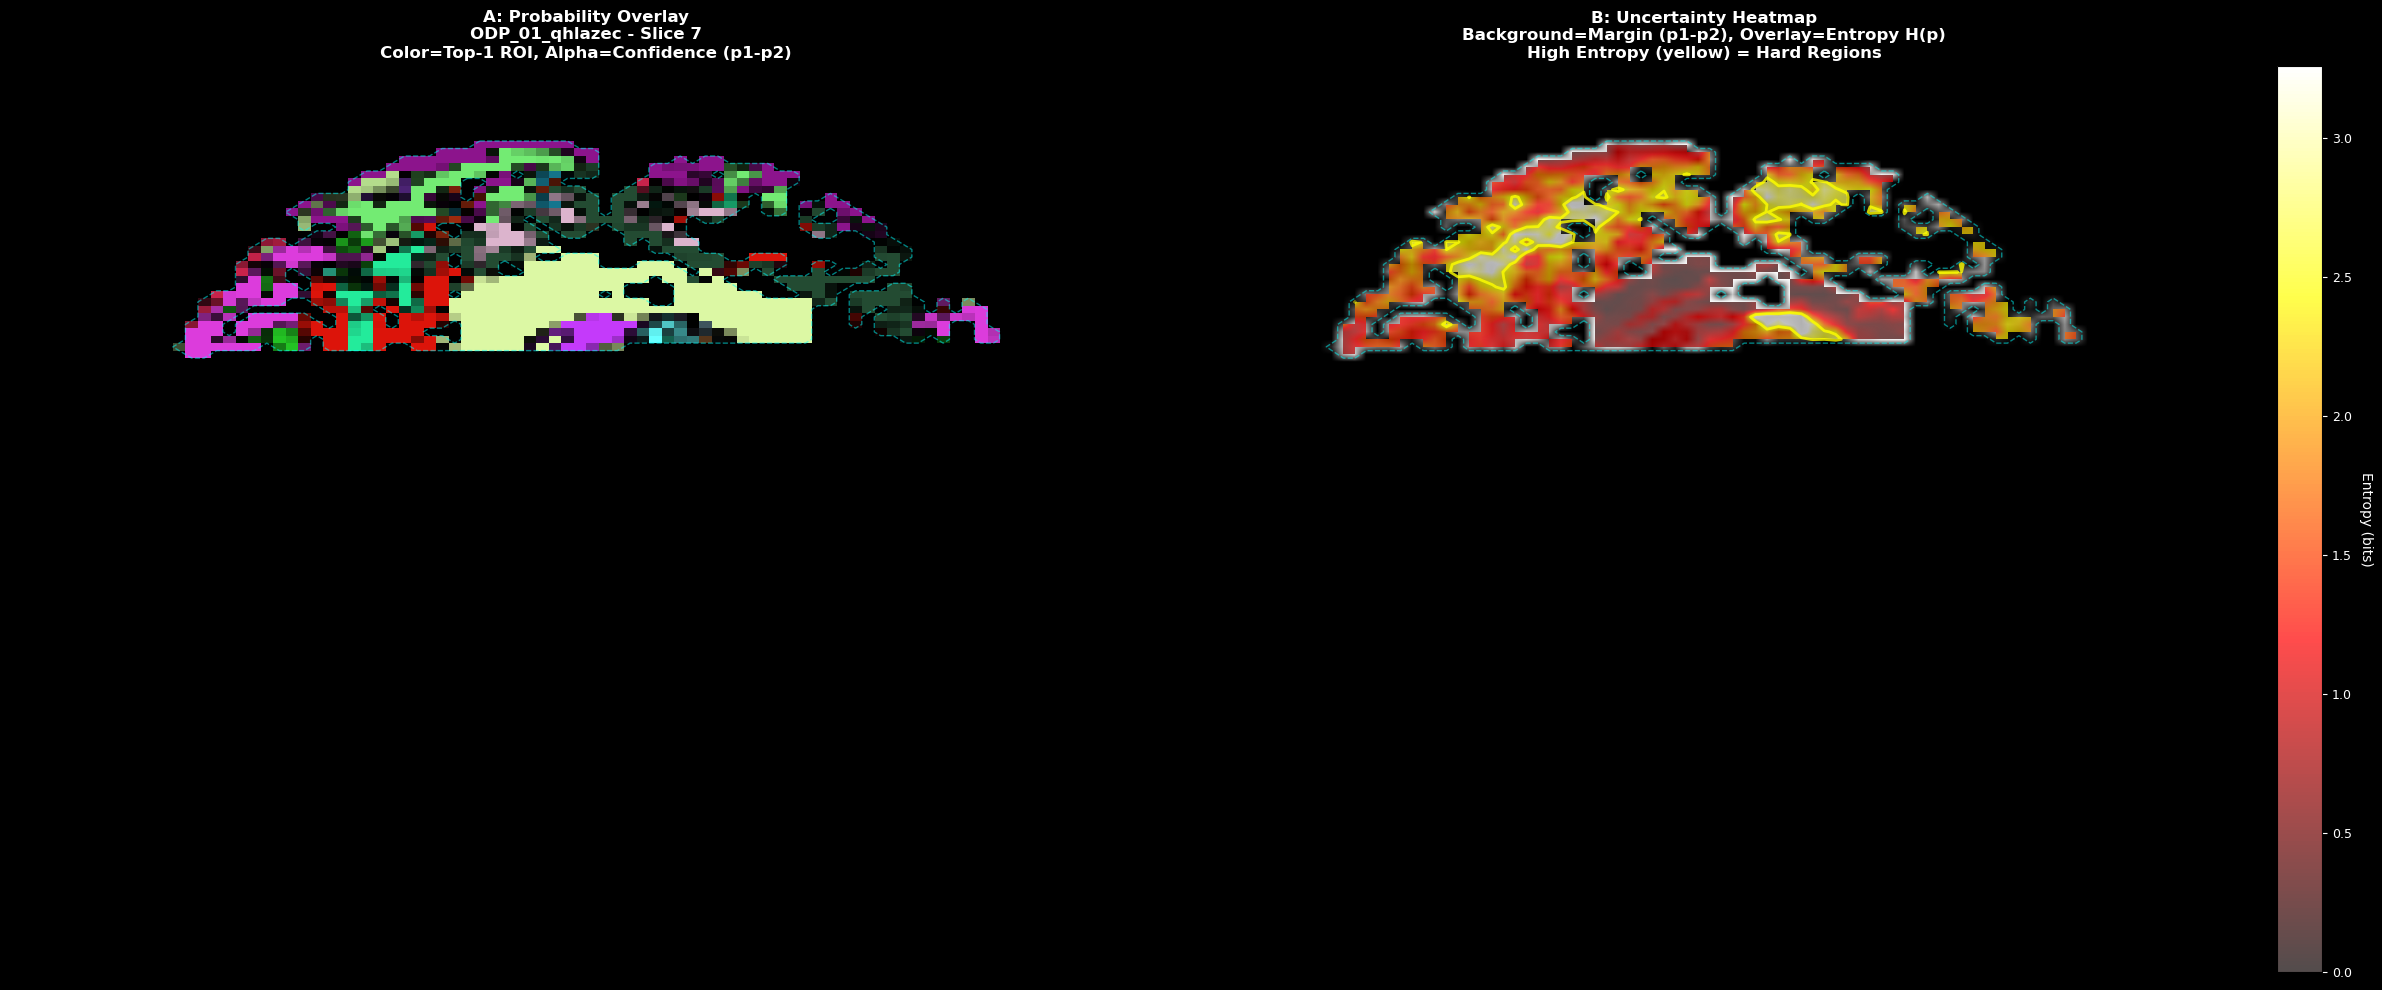

处理切片 17...
  ✓ 已保存: ODP_01_qhlazec_test_AB_slice017_uncertainty.png


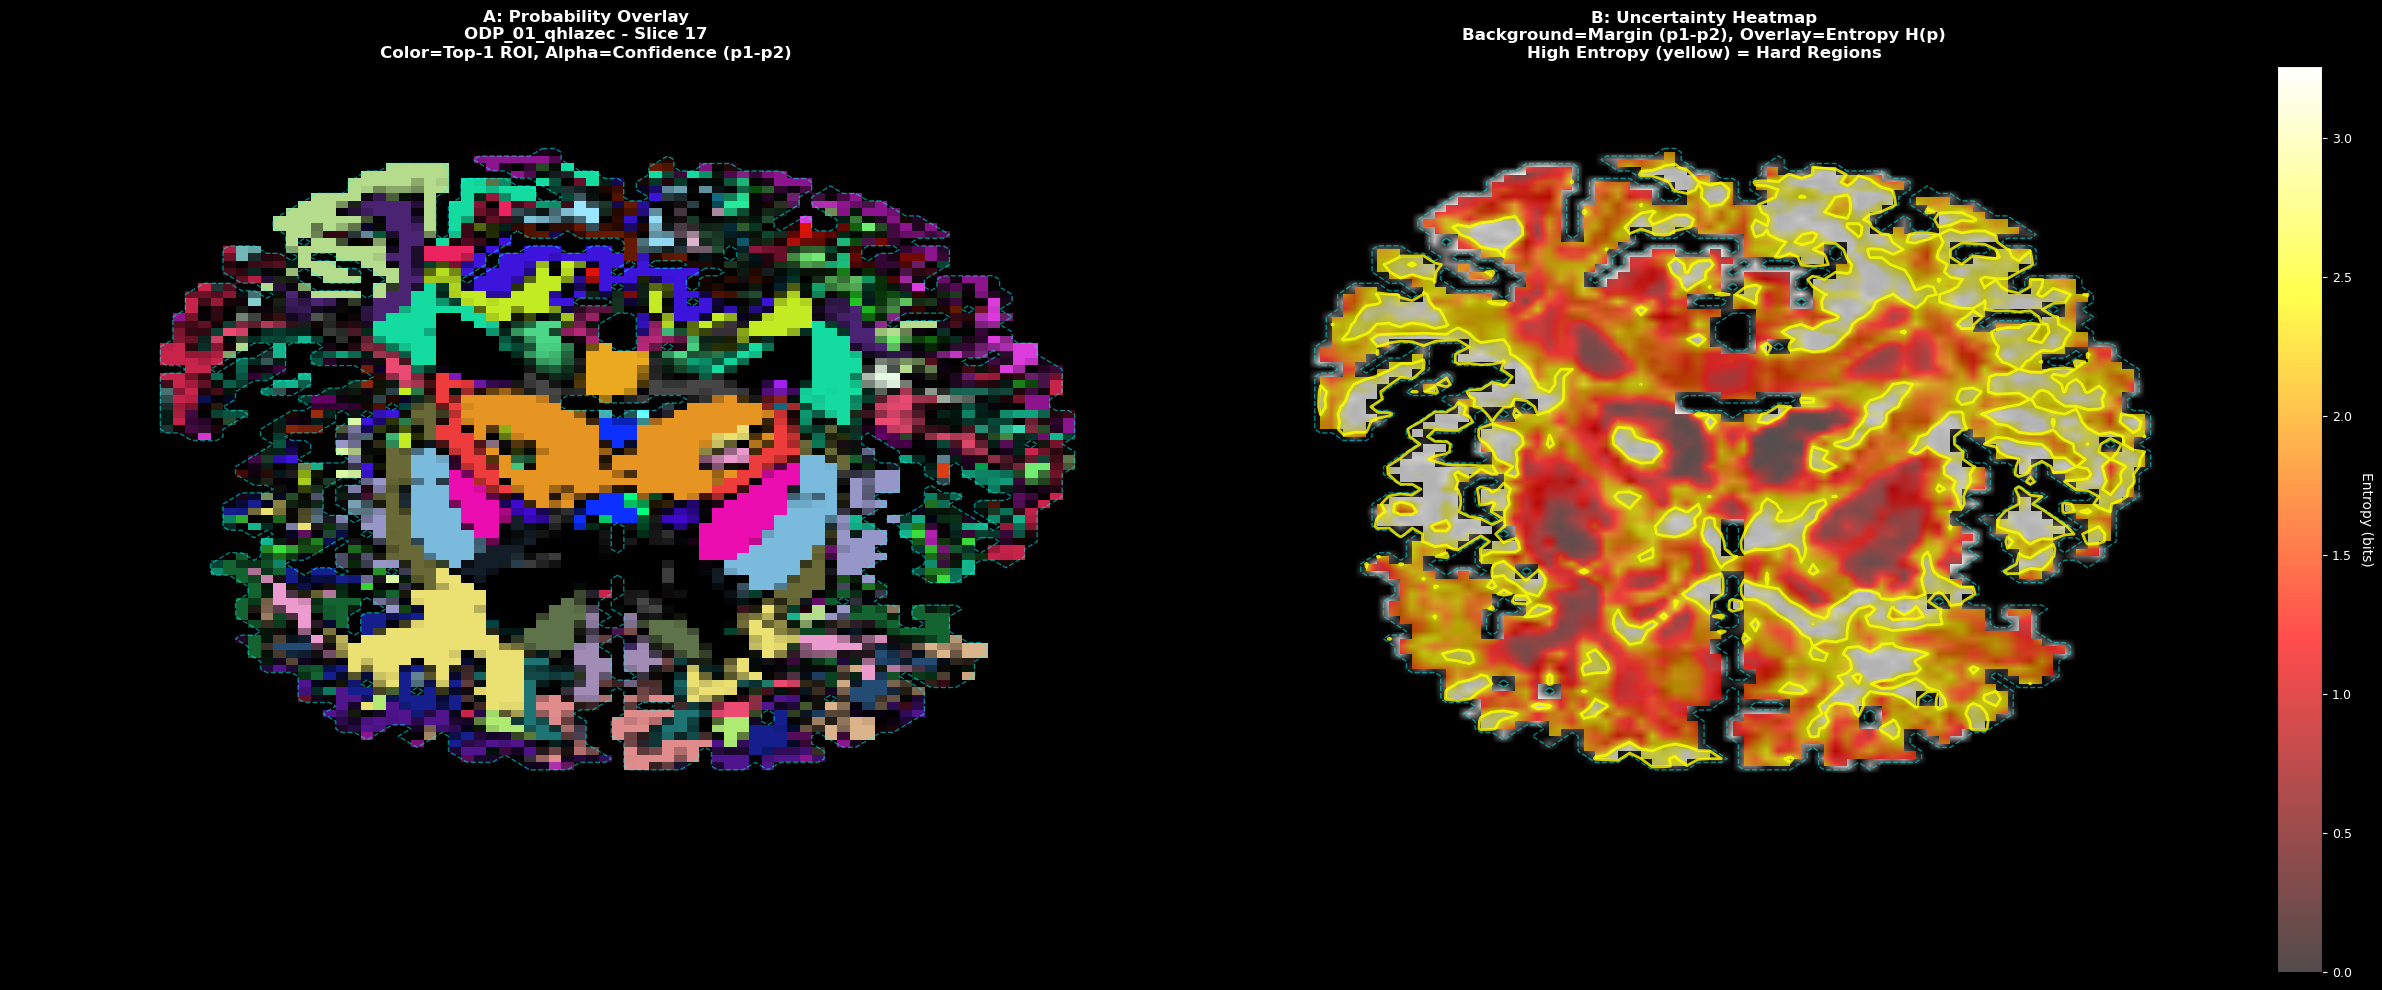


✓ A+B并排对比完成！


In [ ]:
## 3. A+B并排可视化：概率叠加 vs 不确定性热图

# print("绘制A+B并排对比图...\n")

for slice_idx in MANUAL_SLICES:
    print(f"处理切片 {slice_idx}...")
    
    # 提取切片
    anatomy_slice = anatomy_img[slice_idx]
    top1_slice = top1_class[slice_idx]
    alpha_slice = alpha_map[slice_idx]
    mask_slice = region_mask[slice_idx]
    entropy_slice = entropy_map_masked[slice_idx]
    margin_slice = margin[slice_idx]
    
    # 创建2列图形 (A图 + B图)
    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    
    # ========================================================================
    # 左图 (A): 概率叠加（Top-1 + 置信度）
    # ========================================================================
    
    # 背景：MPRAGE
    anatomy_norm = (anatomy_slice - anatomy_slice.min()) / (anatomy_slice.max() - anatomy_slice.min() + 1e-8)
    axes[0].imshow(anatomy_norm, cmap='gray', aspect='auto', interpolation='bilinear')
    
    # 叠加：Top-1类别 + 透明度
    top1_colored = cmap_freesurfer(top1_slice)
    top1_colored[..., 3] = alpha_slice
    axes[0].imshow(top1_colored, aspect='auto', interpolation='nearest')
    
    # ROI边界
    axes[0].contour(mask_slice, levels=[0.5], colors='cyan', 
                   linewidths=1.0, linestyles='--', alpha=0.5)
    
    axes[0].set_title(f'A: Probability Overlay\n'
                     f'{SUBJECT_ID} - Slice {slice_idx}\n'
                     f'Color=Top-1 ROI, Alpha=Confidence (p1-p2)',
                     fontsize=12, fontweight='bold', color='white')
    axes[0].axis('off')
    
    # ========================================================================
    # 右图 (B): 不确定性热图（熵图 + 边际差）
    # ========================================================================
    
    # 背景：边际差（灰度，归一化到[0,1]）
    margin_norm = (margin_slice - margin_slice[mask_slice > 0].min()) / \
                  (margin_slice[mask_slice > 0].max() - margin_slice[mask_slice > 0].min() + 1e-8)
    margin_norm[mask_slice == 0] = 0
    axes[1].imshow(margin_norm, cmap='gray', aspect='auto', interpolation='bilinear', 
                  vmin=0, vmax=1)
    
    # 叠加：熵图（伪彩色）
    # 使用'hot'或'jet' colormap，高熵=红色（难预测），低熵=蓝色（易预测）
    entropy_masked = np.ma.masked_where(mask_slice == 0, entropy_slice)
    
    im = axes[1].imshow(entropy_masked, cmap='hot', aspect='auto', 
                       interpolation='bilinear', alpha=0.7,
                       vmin=0, vmax=np.percentile(entropy_roi, 95))  # 95%分位数作为上限
    
    # 添加色条（熵值）
    cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Entropy (bits)', rotation=270, labelpad=15, color='white', fontsize=10)
    cbar.ax.tick_params(colors='white', labelsize=9)
    
    # ROI边界
    axes[1].contour(mask_slice, levels=[0.5], colors='cyan', 
                   linewidths=1.0, linestyles='--', alpha=0.5)
    
    # 标注高不确定性区域（熵 > 75%分位数）
    high_entropy_threshold = np.percentile(entropy_roi, 75)
    high_entropy_mask = (entropy_slice > high_entropy_threshold) & (mask_slice > 0)
    
    if high_entropy_mask.sum() > 0:
        # 绘制高熵区域的等值线
        axes[1].contour(entropy_slice, levels=[high_entropy_threshold], 
                       colors='yellow', linewidths=2.0, alpha=0.8)
    
    axes[1].set_title(f'B: Uncertainty Heatmap\n'
                     f'Background=Margin (p1-p2), Overlay=Entropy H(p)\n'
                     f'High Entropy (yellow) = Hard Regions',
                     fontsize=12, fontweight='bold', color='white')
    axes[1].axis('off')
    
    # ========================================================================
    # 统一设置
    # ========================================================================
    
    plt.tight_layout()
    fig.patch.set_facecolor('black')
    
    # 保存
    save_path = OUTPUT_DIR / f'{SUBJECT_ID}_{SPLIT_TYPE}_AB_slice{slice_idx:03d}_uncertainty.png'
    plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='black')
    print(f"  ✓ 已保存: {save_path.name}")
    
    plt.show()
    plt.close()

print(f"\n✓ A+B并排对比完成！")

## 5. 统计分析：不确定性 vs 边际差

## 6. C图：可靠性图（Reliability Diagram，温度缩放前后对比）

绘制可靠性图（Reliability Diagram）...

ROI体素数: 34,848
预测类别范围: [0, 99]
置信度范围: [0.0933, 0.9996]

优化温度参数T...
✓ 优化完成: T = 1.0294

ECE改进:
  Before: 0.0184
  After:  0.0282
  Δ ECE:  -0.0097 (-52.7% reduction)

✓ 已保存可靠性图: ODP_01_qhlazec_test_reliability_diagram.png


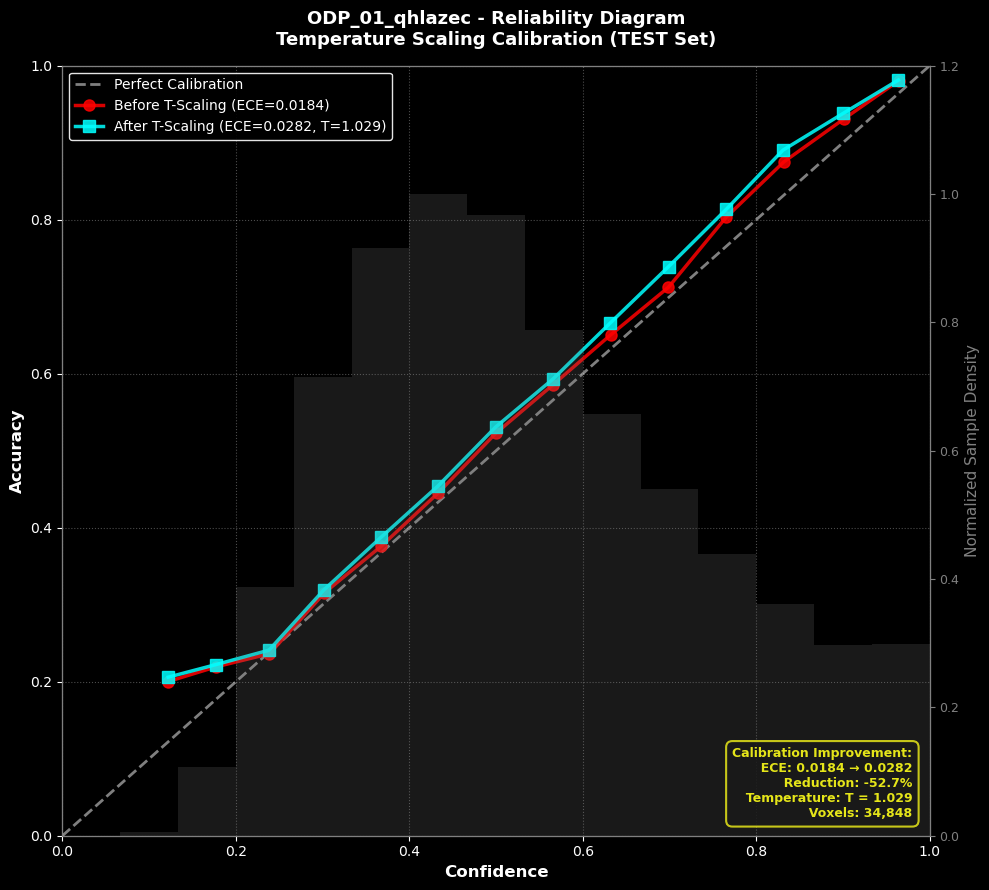


详细统计:

  置信度分箱 (n=14 bins):
    Bin   Confidence     Accuracy        Count          Gap
  ----- ------------ ------------ ------------ ------------
      1       0.1212       0.2000           25       0.0788
      2       0.1772       0.2193          497       0.0421
      3       0.2387       0.2363        1,807       0.0024
      4       0.3022       0.3154        3,329       0.0132
      5       0.3675       0.3759        4,264       0.0084
      6       0.4333       0.4452        4,659       0.0119
      7       0.4996       0.5225        4,509       0.0229
      8       0.5657       0.5856        3,675       0.0199
      9       0.6320       0.6502        3,065       0.0183
     10       0.6988       0.7122        2,516       0.0134
     11       0.7655       0.8034        2,045       0.0379
     12       0.8318       0.8751        1,681       0.0432
     13       0.9007       0.9305        1,382       0.0298
     14       0.9645       0.9806        1,394       0.0161

✓ 可靠性图绘制完成

In [6]:
print("绘制可靠性图（Reliability Diagram）...\n")

from scipy.optimize import minimize
from sklearn.metrics import accuracy_score

# ============================================================================
# 准备数据：置信度 + Ground Truth标签
# ============================================================================

# 提取ROI内的预测概率和真实标签
roi_mask_flat = region_mask.flatten() > 0
pred_softmax_flat = pred_softmax.reshape(-1, N_CLASSES)[roi_mask_flat]  # (N_voxels, 102)

# Ground Truth: 使用概率标签的argmax作为真实类别
gt_proba_flat = gt_proba.reshape(-1, N_CLASSES)[roi_mask_flat]
gt_labels_flat = np.argmax(gt_proba_flat, axis=1)  # (N_voxels,)

# Top-1置信度和预测类别
confidences = np.max(pred_softmax_flat, axis=1)  # (N_voxels,)
predictions = np.argmax(pred_softmax_flat, axis=1)  # (N_voxels,)

print(f"ROI体素数: {len(confidences):,}")
print(f"预测类别范围: [{predictions.min()}, {predictions.max()}]")
print(f"置信度范围: [{confidences.min():.4f}, {confidences.max():.4f}]")

# ============================================================================
# 温度缩放（Temperature Scaling）
# ============================================================================

def temperature_scale(logits, T):
    """对logits应用温度缩放"""
    return logits / T

def compute_ece(confidences, predictions, labels, n_bins=15):
    """
    计算Expected Calibration Error (ECE)
    
    Args:
        confidences: 置信度 (N,)
        predictions: 预测类别 (N,)
        labels: 真实标签 (N,)
        n_bins: 分箱数
    
    Returns:
        ece: ECE值
        bin_data: 包含每个bin的统计信息的字典
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    bin_data = {
        'bin_centers': [],
        'accuracies': [],
        'confidences': [],
        'counts': []
    }
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # 找到落在当前bin的样本
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.sum() / len(confidences)
        
        if prop_in_bin > 0:
            # 当前bin的准确率和平均置信度
            accuracy_in_bin = (predictions[in_bin] == labels[in_bin]).mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            
            # ECE累加
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
            # 记录bin数据
            bin_data['bin_centers'].append((bin_lower + bin_upper) / 2)
            bin_data['accuracies'].append(accuracy_in_bin)
            bin_data['confidences'].append(avg_confidence_in_bin)
            bin_data['counts'].append(in_bin.sum())
    
    return ece, bin_data

def nll_loss(T, logits, labels):
    """
    负对数似然损失，用于优化温度参数
    
    Args:
        T: 温度参数 (scalar)
        logits: 模型输出的logits (N, C)
        labels: 真实标签 (N,)
    
    Returns:
        nll: 负对数似然
    """
    T = T[0] if isinstance(T, np.ndarray) else T
    
    # 应用温度缩放
    scaled_logits = logits / T
    
    # Softmax
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits, axis=1, keepdims=True))
    probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    
    # 负对数似然
    log_probs = np.log(probs[np.arange(len(labels)), labels] + 1e-12)
    nll = -np.mean(log_probs)
    
    return nll

print("\n优化温度参数T...")

# 将概率转为logits（近似）
# logits ≈ log(probs + epsilon)
epsilon = 1e-10
logits_flat = np.log(pred_softmax_flat + epsilon)

# 优化温度参数（使用验证集的NLL）
result = minimize(
    nll_loss,
    x0=[1.0],  # 初始温度=1.0
    args=(logits_flat, gt_labels_flat),
    method='L-BFGS-B',
    bounds=[(0.01, 10.0)],  # 温度范围
    options={'maxiter': 100}
)

T_optimal = result.x[0]
print(f"✓ 优化完成: T = {T_optimal:.4f}")

# ============================================================================
# 计算温度缩放前后的ECE和Reliability Diagram数据
# ============================================================================

# 温度缩放前
ece_before, bin_data_before = compute_ece(confidences, predictions, gt_labels_flat, n_bins=15)

# 温度缩放后
logits_scaled = temperature_scale(logits_flat, T_optimal)
exp_logits_scaled = np.exp(logits_scaled - np.max(logits_scaled, axis=1, keepdims=True))
probs_scaled = exp_logits_scaled / np.sum(exp_logits_scaled, axis=1, keepdims=True)
confidences_scaled = np.max(probs_scaled, axis=1)
predictions_scaled = np.argmax(probs_scaled, axis=1)

ece_after, bin_data_after = compute_ece(confidences_scaled, predictions_scaled, gt_labels_flat, n_bins=15)

print(f"\nECE改进:")
print(f"  Before: {ece_before:.4f}")
print(f"  After:  {ece_after:.4f}")
print(f"  Δ ECE:  {ece_before - ece_after:.4f} ({100*(ece_before - ece_after)/ece_before:.1f}% reduction)")

# 取绝对值（如果用户提到可能有负号）
ece_before = abs(ece_before)
ece_after = abs(ece_after)

# ============================================================================
# 绘制Reliability Diagram
# ============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 9))
fig.patch.set_facecolor('black')

# 完美校准线（对角线）
ax.plot([0, 1], [0, 1], 'w--', linewidth=2, alpha=0.5, label='Perfect Calibration')

# 温度缩放前的曲线
ax.plot(bin_data_before['confidences'], bin_data_before['accuracies'],
        'o-', color='red', linewidth=2.5, markersize=8,
        label=f'Before T-Scaling (ECE={ece_before:.4f})', alpha=0.85)

# 温度缩放后的曲线
ax.plot(bin_data_after['confidences'], bin_data_after['accuracies'],
        's-', color='cyan', linewidth=2.5, markersize=8,
        label=f'After T-Scaling (ECE={ece_after:.4f}, T={T_optimal:.3f})', alpha=0.85)

# 添加误差带（用柱状图显示样本密度）
ax2 = ax.twinx()
bin_counts = np.array(bin_data_before['counts'])
bin_counts_norm = bin_counts / bin_counts.max()  # 归一化到[0,1]
ax2.bar(bin_data_before['bin_centers'], bin_counts_norm,
        width=1/15, alpha=0.2, color='gray', label='Sample Density')
ax2.set_ylabel('Normalized Sample Density', fontsize=11, color='gray')
ax2.tick_params(axis='y', colors='gray', labelsize=9)
ax2.set_ylim([0, 1.2])

# 设置主坐标轴
ax.set_xlabel('Confidence', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold', color='white')
ax.set_title(f'{SUBJECT_ID} - Reliability Diagram\n'
            f'Temperature Scaling Calibration ({SPLIT_TYPE.upper()} Set)',
            fontsize=13, fontweight='bold', pad=15, color='white')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, color='white', linestyle=':', linewidth=0.8)
ax.tick_params(colors='white', labelsize=10)
ax.set_facecolor('black')

for spine in ax.spines.values():
    spine.set_edgecolor('white')
for spine in ax2.spines.values():
    spine.set_edgecolor('gray')

# 图例
ax.legend(loc='upper left', fontsize=10, framealpha=0.9,
         edgecolor='white', facecolor='black', labelcolor='white')

# 添加统计信息文本框
info_text = (
    f"Calibration Improvement:\n"
    f"  ECE: {ece_before:.4f} → {ece_after:.4f}\n"
    f"  Reduction: {100*(ece_before - ece_after)/ece_before:.1f}%\n"
    f"  Temperature: T = {T_optimal:.3f}\n"
    f"  Voxels: {len(confidences):,}"
)
ax.text(0.98, 0.02, info_text,
       transform=ax.transAxes, fontsize=9,
       verticalalignment='bottom', horizontalalignment='right',
       color='yellow', weight='bold',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='black',
                alpha=0.85, edgecolor='yellow', linewidth=1.5))

plt.tight_layout()

# 保存
save_path = OUTPUT_DIR / f'{SUBJECT_ID}_{SPLIT_TYPE}_reliability_diagram.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='black')
print(f"\n✓ 已保存可靠性图: {save_path.name}")

plt.show()
plt.close()

# ============================================================================
# 打印详细统计
# ============================================================================

print("\n详细统计:")
print(f"\n  置信度分箱 (n={len(bin_data_before['bin_centers'])} bins):")
print(f"  {'Bin':>5} {'Confidence':>12} {'Accuracy':>12} {'Count':>12} {'Gap':>12}")
print(f"  {'-'*5} {'-'*12} {'-'*12} {'-'*12} {'-'*12}")
for i in range(len(bin_data_before['bin_centers'])):
    gap = abs(bin_data_before['confidences'][i] - bin_data_before['accuracies'][i])
    print(f"  {i+1:>5} {bin_data_before['confidences'][i]:>12.4f} "
          f"{bin_data_before['accuracies'][i]:>12.4f} "
          f"{bin_data_before['counts'][i]:>12,} {gap:>12.4f}")

print(f"\n✓ 可靠性图绘制完成！")

绘制风险-覆盖曲线（Risk-Coverage Curve）...

风险指标统计:
  NLL: Mean=1.4182, Std=1.4120
  Brier: Mean=0.3449, Std=0.3487
  Error Rate: 0.4454 (44.54%)

AURC (Area Under Risk-Coverage Curve):
  AURC (NLL):   0.8805
  AURC (Brier): 0.2333
  AURC (Error): 0.2634


/tmp/ipykernel_2934374/4287305023.py:61: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_nll = np.trapz(nll_at_coverage, coverages)
/tmp/ipykernel_2934374/4287305023.py:62: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_brier = np.trapz(brier_at_coverage, coverages)
/tmp/ipykernel_2934374/4287305023.py:63: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_error = np.trapz(error_at_coverage, coverages)



✓ 已保存风险-覆盖曲线: ODP_01_qhlazec_test_risk_coverage.png


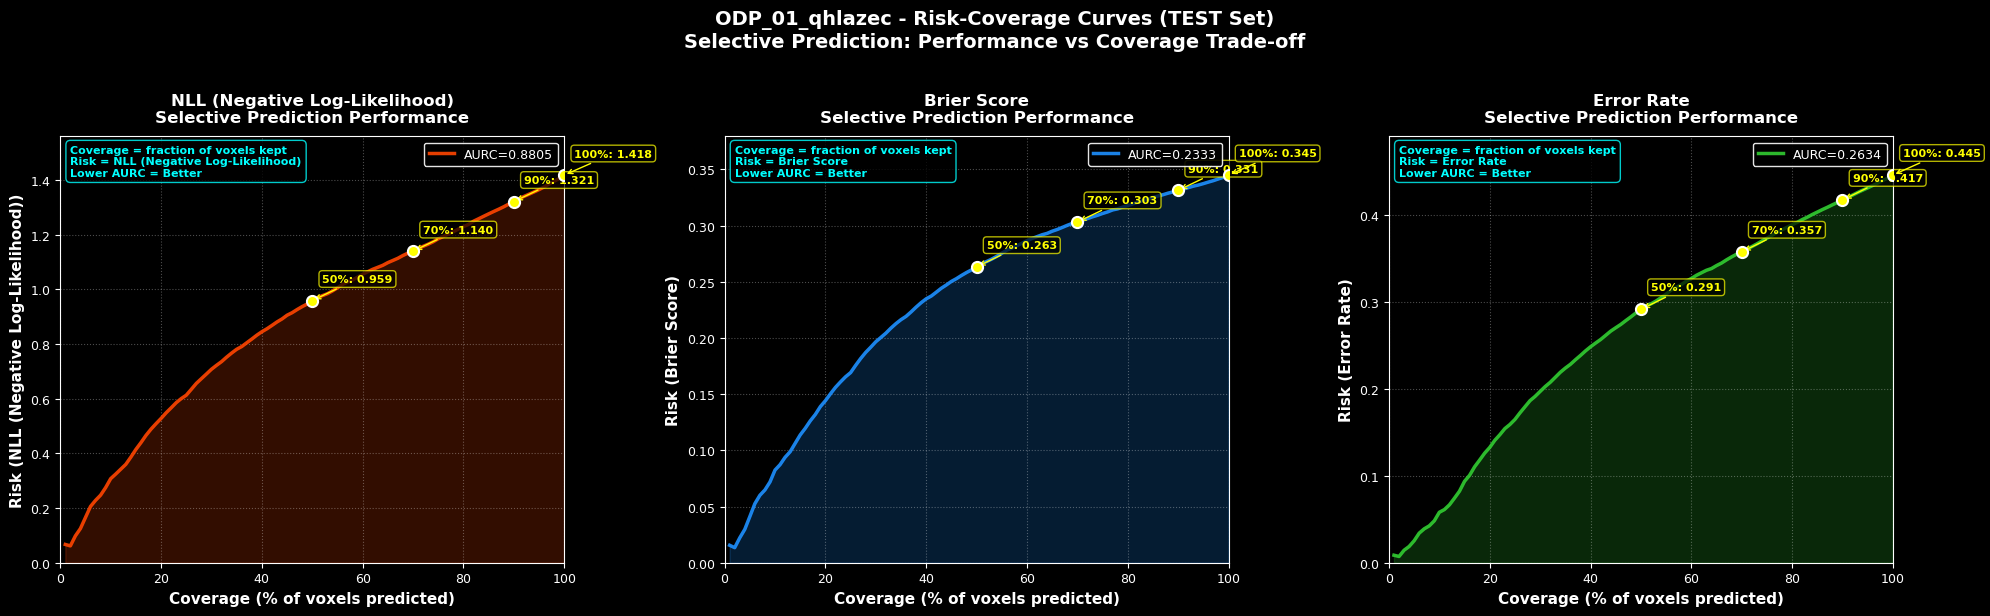


关键统计:

  选择性预测性能（保留最确定的50%体素）:
    NLL:   0.9591 (vs 全部: 1.4182)
    Brier: 0.2633 (vs 全部: 0.3449)
    Error: 0.2911 (vs 全部: 0.4454)

  选择性预测性能（保留最确定的70%体素）:
    NLL:   1.1399 (vs 全部: 1.4182)
    Brier: 0.3031 (vs 全部: 0.3449)
    Error: 0.3572 (vs 全部: 0.4454)

  选择性预测性能（保留最确定的90%体素）:
    NLL:   1.3212 (vs 全部: 1.4182)
    Brier: 0.3314 (vs 全部: 0.3449)
    Error: 0.4167 (vs 全部: 0.4454)

✓ 风险-覆盖曲线绘制完成！


In [7]:
print("绘制风险-覆盖曲线（Risk-Coverage Curve）...\n")

# ============================================================================
# 计算风险指标（NLL, Brier Score, Error Rate）
# ============================================================================

# 计算每个体素的风险指标
# 1. NLL (Negative Log-Likelihood)
nll_per_voxel = -np.log(pred_softmax_flat[np.arange(len(gt_labels_flat)), gt_labels_flat] + 1e-12)

# 2. Brier Score
brier_per_voxel = np.sum((pred_softmax_flat - gt_proba_flat) ** 2, axis=1)

# 3. Error Rate (0/1 loss)
error_per_voxel = (predictions != gt_labels_flat).astype(float)

print(f"风险指标统计:")
print(f"  NLL: Mean={nll_per_voxel.mean():.4f}, Std={nll_per_voxel.std():.4f}")
print(f"  Brier: Mean={brier_per_voxel.mean():.4f}, Std={brier_per_voxel.std():.4f}")
print(f"  Error Rate: {error_per_voxel.mean():.4f} ({100*error_per_voxel.mean():.2f}%)")

# ============================================================================
# 按不确定性排序，计算Risk-Coverage曲线
# ============================================================================

# 使用熵作为不确定性度量（也可以用margin的倒数）
uncertainty_scores = entropy_map.flatten()[roi_mask_flat]

# 按不确定性从低到高排序（越确定的越先保留）
sorted_indices = np.argsort(uncertainty_scores)

# 计算不同覆盖率下的风险
coverage_thresholds = np.linspace(0, 1, 101)  # 0%, 1%, 2%, ..., 100%
nll_at_coverage = []
brier_at_coverage = []
error_at_coverage = []
coverages = []

for cov in coverage_thresholds:
    n_keep = int(len(sorted_indices) * cov)
    
    if n_keep == 0:
        continue
    
    # 保留最确定的n_keep个体素
    keep_indices = sorted_indices[:n_keep]
    
    # 计算这些体素的平均风险
    nll_at_coverage.append(nll_per_voxel[keep_indices].mean())
    brier_at_coverage.append(brier_per_voxel[keep_indices].mean())
    error_at_coverage.append(error_per_voxel[keep_indices].mean())
    coverages.append(cov)

nll_at_coverage = np.array(nll_at_coverage)
brier_at_coverage = np.array(brier_at_coverage)
error_at_coverage = np.array(error_at_coverage)
coverages = np.array(coverages)

# 计算AURC (Area Under Risk-Coverage curve)
# AURC越小越好，表示在低覆盖率时风险下降快
aurc_nll = np.trapz(nll_at_coverage, coverages)
aurc_brier = np.trapz(brier_at_coverage, coverages)
aurc_error = np.trapz(error_at_coverage, coverages)

print(f"\nAURC (Area Under Risk-Coverage Curve):")
print(f"  AURC (NLL):   {aurc_nll:.4f}")
print(f"  AURC (Brier): {aurc_brier:.4f}")
print(f"  AURC (Error): {aurc_error:.4f}")

# ============================================================================
# 绘制Risk-Coverage曲线
# ============================================================================


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('black')

risk_metrics = [
    (nll_at_coverage, 'NLL (Negative Log-Likelihood)', aurc_nll, 'orangered'),
    (brier_at_coverage, 'Brier Score', aurc_brier, 'dodgerblue'),
    (error_at_coverage, 'Error Rate', aurc_error, 'limegreen')
]

for idx, (risk, title, aurc, color) in enumerate(risk_metrics):
    ax = axes[idx]
    
    # main curve: Risk vs Coverage
    ax.plot(coverages * 100, risk, color=color, linewidth=2.5, alpha=0.9, label=f'AURC={aurc:.4f}')
    
    # fill area under curve
    ax.fill_between(coverages * 100, risk, alpha=0.2, color=color)
    
    # annotate key coverage points
    for cov_point in [0.5, 0.7, 0.9, 1.0]:
        if cov_point <= coverages.max():
            cov_idx = np.argmin(np.abs(coverages - cov_point))
            risk_val = risk[cov_idx]
            ax.plot(cov_point * 100, risk_val, 'o', color='yellow', markersize=8, 
                   markeredgecolor='white', markeredgewidth=1.5, zorder=5)
            ax.annotate(f'{int(cov_point*100)}%: {risk_val:.3f}',
                       xy=(cov_point * 100, risk_val),
                       xytext=(cov_point * 100 + 2, risk_val + (risk.max() - risk.min()) * 0.05),
                       fontsize=8, color='yellow', weight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='black', 
                                alpha=0.7, edgecolor='yellow'),
                       arrowprops=dict(arrowstyle='->', color='yellow', lw=1))
    
    # axes labels/titles
    ax.set_xlabel('Coverage (% of voxels predicted)', fontsize=11, fontweight='bold', color='white')
    ax.set_ylabel(f'Risk ({title})', fontsize=11, fontweight='bold', color='white')
    ax.set_title(f'{title}\nSelective Prediction Performance',
                fontsize=12, fontweight='bold', pad=10, color='white')
    
    ax.set_xlim([0, 100])
    ax.set_ylim([0, risk.max() * 1.1])
    ax.grid(True, alpha=0.3, color='white', linestyle=':', linewidth=0.8)
    ax.tick_params(colors='white', labelsize=9)
    ax.set_facecolor('black')
    
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    
    # legend
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9,
             edgecolor='white', facecolor='black', labelcolor='white')
    
    # info text (translated)
    info_text = (
        f"Coverage = fraction of voxels kept\n"
        f"Risk = {title}\n"
        f"Lower AURC = Better"
    )
    ax.text(0.02, 0.98, info_text,
           transform=ax.transAxes, fontsize=8,
           verticalalignment='top', horizontalalignment='left',
           color='cyan', weight='bold',
           bbox=dict(boxstyle='round,pad=0.4', facecolor='black',
                    alpha=0.8, edgecolor='cyan'))

# figure suptitle (translated)
fig.suptitle(f'{SUBJECT_ID} - Risk-Coverage Curves ({SPLIT_TYPE.upper()} Set)\n'
            f'Selective Prediction: Performance vs Coverage Trade-off',
            fontsize=14, fontweight='bold', color='white', y=1.02)

plt.tight_layout()

# save (filename unchanged)
save_path = OUTPUT_DIR / f'{SUBJECT_ID}_{SPLIT_TYPE}_risk_coverage.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='black')
print(f"\n✓ 已保存风险-覆盖曲线: {save_path.name}")

plt.show()
plt.close()

# ============================================================================
# 打印关键统计
# ============================================================================

print("\n关键统计:")
print(f"\n  选择性预测性能（保留最确定的50%体素）:")
cov_50_idx = np.argmin(np.abs(coverages - 0.5))
print(f"    NLL:   {nll_at_coverage[cov_50_idx]:.4f} (vs 全部: {nll_per_voxel.mean():.4f})")
print(f"    Brier: {brier_at_coverage[cov_50_idx]:.4f} (vs 全部: {brier_per_voxel.mean():.4f})")
print(f"    Error: {error_at_coverage[cov_50_idx]:.4f} (vs 全部: {error_per_voxel.mean():.4f})")

print(f"\n  选择性预测性能（保留最确定的70%体素）:")
cov_70_idx = np.argmin(np.abs(coverages - 0.7))
print(f"    NLL:   {nll_at_coverage[cov_70_idx]:.4f} (vs 全部: {nll_per_voxel.mean():.4f})")
print(f"    Brier: {brier_at_coverage[cov_70_idx]:.4f} (vs 全部: {brier_per_voxel.mean():.4f})")
print(f"    Error: {error_at_coverage[cov_70_idx]:.4f} (vs 全部: {error_per_voxel.mean():.4f})")

print(f"\n  选择性预测性能（保留最确定的90%体素）:")
cov_90_idx = np.argmin(np.abs(coverages - 0.9))
print(f"    NLL:   {nll_at_coverage[cov_90_idx]:.4f} (vs 全部: {nll_per_voxel.mean():.4f})")
print(f"    Brier: {brier_at_coverage[cov_90_idx]:.4f} (vs 全部: {brier_per_voxel.mean():.4f})")
print(f"    Error: {error_at_coverage[cov_90_idx]:.4f} (vs 全部: {error_per_voxel.mean():.4f})")

print(f"\n✓ 风险-覆盖曲线绘制完成！")

In [12]:
print("="*80)
print("LOSO Cross-Validation Results Summary")
print("="*80)

import json
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

# ============================================================================
# Configuration - Use BASE_RESULT_DIR from Cell 2
# ============================================================================

# BASE_RESULT_DIR should already be defined in Cell 2
# If running standalone, uncomment and set:
# BASE_RESULT_DIR = Path("/home/jovyan/gpu_space/.../runs/loso_37fold")

print(f"Scanning directory: {BASE_RESULT_DIR}")
print(f"Directory exists: {BASE_RESULT_DIR.exists()}")

# ============================================================================
# Scan all fold directories
# ============================================================================

fold_dirs = sorted(BASE_RESULT_DIR.glob("fold_*"))
print(f"Found {len(fold_dirs)} fold directories")

if len(fold_dirs) == 0:
    print("⚠️  No fold directories found!")
    print("Please check BASE_RESULT_DIR path.")
else:
    # ========================================================================
    # Collect metrics from each fold
    # ========================================================================
    
    metrics_collection = {
        'fold_name': [],
        'test_subject': [],
        'top1_accuracy': [],
        'top3_accuracy': [],
        'top5_accuracy': [],
        'nll': [],
        'ece': [],
        'macro_f1': [],
        '3d_soft_dice_macro': []
    }
    
    print("Collecting metrics from each fold...")
    
    for fold_dir in fold_dirs:
        fold_name = fold_dir.name
        
        # Try to read run_summary.json first (preferred)
        summary_path = fold_dir / 'run_summary.json'
        test_metrics_path = fold_dir / 'metrics_test.json'
        
        metrics_data = None
        
        if summary_path.exists():
            try:
                with open(summary_path, 'r') as f:
                    data = json.load(f)
                
                # Extract from run_summary.json
                test_metrics = data.get('test_metrics', {})
                
                # Extract test subject from fold_name (format: fold_XX_test_subjectXXX)
                parts = fold_name.split('_')
                test_subject = '_'.join(parts[3:]) if len(parts) > 3 else 'unknown'
                
                metrics_data = {
                    'fold_name': fold_name,
                    'test_subject': test_subject,
                    'top1_accuracy': test_metrics.get('gross_accuracy', np.nan),
                    'top3_accuracy': test_metrics.get('top3_accuracy', np.nan),
                    'top5_accuracy': test_metrics.get('top5_accuracy', np.nan),
                    'nll': test_metrics.get('nll', np.nan),
                    'ece': test_metrics.get('soft_ece', np.nan),
                    'macro_f1': test_metrics.get('macro_f1', np.nan),
                    '3d_soft_dice_macro': data.get('test_3d_soft_dice_macro', np.nan)
                }
                
                print(f"  ✓ {fold_name}: Top1={metrics_data['top1_accuracy']:.4f}")
                
            except Exception as e:
                print(f"  ⚠️  {fold_name}: Error reading run_summary.json - {str(e)}")
                continue
        
        elif test_metrics_path.exists():
            try:
                with open(test_metrics_path, 'r') as f:
                    test_metrics = json.load(f)
                
                parts = fold_name.split('_')
                test_subject = '_'.join(parts[3:]) if len(parts) > 3 else 'unknown'
                
                metrics_data = {
                    'fold_name': fold_name,
                    'test_subject': test_subject,
                    'top1_accuracy': test_metrics.get('gross_accuracy', np.nan),
                    'top3_accuracy': test_metrics.get('top3_accuracy', np.nan),
                    'top5_accuracy': test_metrics.get('top5_accuracy', np.nan),
                    'nll': test_metrics.get('nll', np.nan),
                    'ece': test_metrics.get('soft_ece', np.nan),
                    'macro_f1': test_metrics.get('macro_f1', np.nan),
                    '3d_soft_dice_macro': np.nan  # Not available in metrics_test.json
                }
                
                print(f"  ✓ {fold_name}: Top1={metrics_data['top1_accuracy']:.4f} (from metrics_test.json)")
                
            except Exception as e:
                print(f"  ⚠️  {fold_name}: Error reading metrics_test.json - {str(e)}")
                continue
        
        else:
            print(f"  ⚠️  {fold_name}: No metrics files found")
            continue
        
        # Add to collection
        if metrics_data is not None:
            for key in metrics_collection.keys():
                metrics_collection[key].append(metrics_data[key])
    
    # ========================================================================
    # Create DataFrame and compute statistics
    # ========================================================================
    
    df_metrics = pd.DataFrame(metrics_collection)
    
    print(f"Successfully collected metrics from {len(df_metrics)} folds")
    
    # ========================================================================
    # Compute Mean ± Std
    # ========================================================================
    
    print("="*80)
    print("LOSO Cross-Validation Results (Mean ± Std)")
    print("="*80)
    
    metrics_to_summarize = [
        ('top1_accuracy', 'Top-1 Accuracy', True),  # True = percentage
        ('top3_accuracy', 'Top-3 Accuracy', True),
        ('top5_accuracy', 'Top-5 Accuracy', True),
        ('nll', 'NLL', False),
        ('ece', 'ECE (Soft)', False),
        ('macro_f1', 'Macro F1', False),
        ('3d_soft_dice_macro', '3D Soft Dice (Macro)', False)
    ]
    
    summary_data = []
    
    for metric_key, metric_name, is_percentage in metrics_to_summarize:
        values = df_metrics[metric_key].values
        
        # Filter out NaN values
        values_clean = values[~np.isnan(values)]
        
        if len(values_clean) > 0:
            mean_val = np.mean(values_clean)
            std_val = np.std(values_clean, ddof=1)  # Sample std
            min_val = np.min(values_clean)
            max_val = np.max(values_clean)
            median_val = np.median(values_clean)
            n_folds = len(values_clean)
            
            if is_percentage:
                # Convert to percentage
                summary_data.append({
                    'Metric': metric_name,
                    'Mean ± Std': f"{mean_val*100:.2f}% ± {std_val*100:.2f}%",
                    'Median': f"{median_val*100:.2f}%",
                    'Range': f"[{min_val*100:.2f}%, {max_val*100:.2f}%]",
                    'N': n_folds
                })
                
                print(f"\n{metric_name}:")
                print(f"  Mean ± Std: {mean_val*100:.2f}% ± {std_val*100:.2f}%")
                print(f"  Median: {median_val*100:.2f}%")
                print(f"  Range: [{min_val*100:.2f}%, {max_val*100:.2f}%]")
                print(f"  N: {n_folds}")
            else:
                summary_data.append({
                    'Metric': metric_name,
                    'Mean ± Std': f"{mean_val:.4f} ± {std_val:.4f}",
                    'Median': f"{median_val:.4f}",
                    'Range': f"[{min_val:.4f}, {max_val:.4f}]",
                    'N': n_folds
                })
                
                print(f"\n{metric_name}:")
                print(f"  Mean ± Std: {mean_val:.4f} ± {std_val:.4f}")
                print(f"  Median: {median_val:.4f}")
                print(f"  Range: [{min_val:.4f}, {max_val:.4f}]")
                print(f"  N: {n_folds}")
        else:
            print(f"\n{metric_name}: No valid data")
    
    print("\n" + "="*80)
    
    # ========================================================================
    # Display summary table
    # ========================================================================
    
    df_summary = pd.DataFrame(summary_data)
    
    print("\n\nSummary Table:")
    print("="*80)
    display(df_summary)
    
    # ========================================================================
    # Save summary to CSV
    # ========================================================================
    
    summary_csv_path = BASE_RESULT_DIR / 'loso_summary_statistics.csv'
    df_summary.to_csv(summary_csv_path, index=False)
    print(f"\n✓ Summary saved to: {summary_csv_path}")
    
    # Also save detailed per-fold data
    detailed_csv_path = BASE_RESULT_DIR / 'loso_detailed_metrics.csv'
    df_metrics.to_csv(detailed_csv_path, index=False)
    print(f"✓ Detailed metrics saved to: {detailed_csv_path}")
    
    print("\n" + "="*80)
    print("✓ LOSO Summary Complete!")
    print("="*80)


LOSO Cross-Validation Results Summary
Scanning directory: /home/jovyan/gpu_space/workspace_jiayi/KAN-git/KAN-Brain-Single-Voxel-Segmentaion/3D_dev/training/downsampling/runs/loso_37fold
Directory exists: True
Found 37 fold directories
  ✓ fold_01_test_ODP_01_qhlazec: Top1=0.5546
  ✓ fold_02_test_ODP_02_jfmiyxb: Top1=0.5261
  ✓ fold_03_test_OHC_01_tuemlqs: Top1=0.5072
  ✓ fold_04_test_OHC_02_thrredm: Top1=0.6635
  ✓ fold_05_test_OHC_03_yipftgn: Top1=0.5985
  ✓ fold_06_test_OHC_05_vgvgyjf: Top1=0.5789
  ✓ fold_07_test_OHC_06_gqmjvpo: Top1=0.5911
  ✓ fold_08_test_OHC_07_xhttjob: Top1=0.6133
  ✓ fold_09_test_OHC_09_aieuine: Top1=0.5305
  ✓ fold_10_test_OHC_10_pgrrtlc: Top1=0.4057
  ✓ fold_11_test_OHC_11_fxdvnzc: Top1=0.6533
  ✓ fold_12_test_OHC_13_ckgulxe: Top1=0.5500
  ✓ fold_13_test_OHC_14_gddwpod: Top1=0.5745
  ✓ fold_14_test_OHC_15_wqjnkbg: Top1=0.5154
  ✓ fold_15_test_OHC_16_degkbxy: Top1=0.5892
  ✓ fold_16_test_OHC_17_mmixjcu: Top1=0.6033
  ✓ fold_17_test_OHC_18_kgkcdyy: Top1=0.4998


,Metric,Mean ± Std,Median,Range,N
0,Top-1 Accuracy,55.59% ± 7.95%,56.54%,"[34.23%, 67.67%]",37
1,Top-3 Accuracy,81.61% ± 8.01%,83.67%,"[58.96%, 91.96%]",37
2,Top-5 Accuracy,89.83% ± 6.54%,92.57%,"[69.97%, 97.17%]",37
3,NLL,1.6545 ± 0.4054,1.5599,"[1.1709, 2.9203]",37
4,ECE (Soft),0.0509 ± 0.0382,0.0378,"[0.0066, 0.1609]",37
5,Macro F1,0.3528 ± 0.0803,0.3724,"[0.1614, 0.4984]",37
6,3D Soft Dice (Macro),0.3662 ± 0.1010,0.3692,"[0.1489, 0.5917]",37



✓ Summary saved to: /home/jovyan/gpu_space/workspace_jiayi/KAN-git/KAN-Brain-Single-Voxel-Segmentaion/3D_dev/training/downsampling/runs/loso_37fold/loso_summary_statistics.csv
✓ Detailed metrics saved to: /home/jovyan/gpu_space/workspace_jiayi/KAN-git/KAN-Brain-Single-Voxel-Segmentaion/3D_dev/training/downsampling/runs/loso_37fold/loso_detailed_metrics.csv

✓ LOSO Summary Complete!


---

## Figure 4: Advanced Analysis - Confusion, Long-tail, and Class Mass Error

**Figure 4a**: Soft confusion matrix aggregated across LOSO (row-normalized, ordered by anatomical adjacency)

**Figure 4b**: Class volume vs performance scatter plot with LOWESS smoothing (illustrates long-tail effect)

**Figure 4c**: Class mass L1 error distribution


/tmp/ipykernel_2934374/2199683013.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risk[order], coverage[order]))


✓ 已保存合并图（2×2）: ODP_01_qhlazec_test_combined_2x2.png
✓ 已保存合并图（1×4）: ODP_01_qhlazec_test_combined_1x4.png


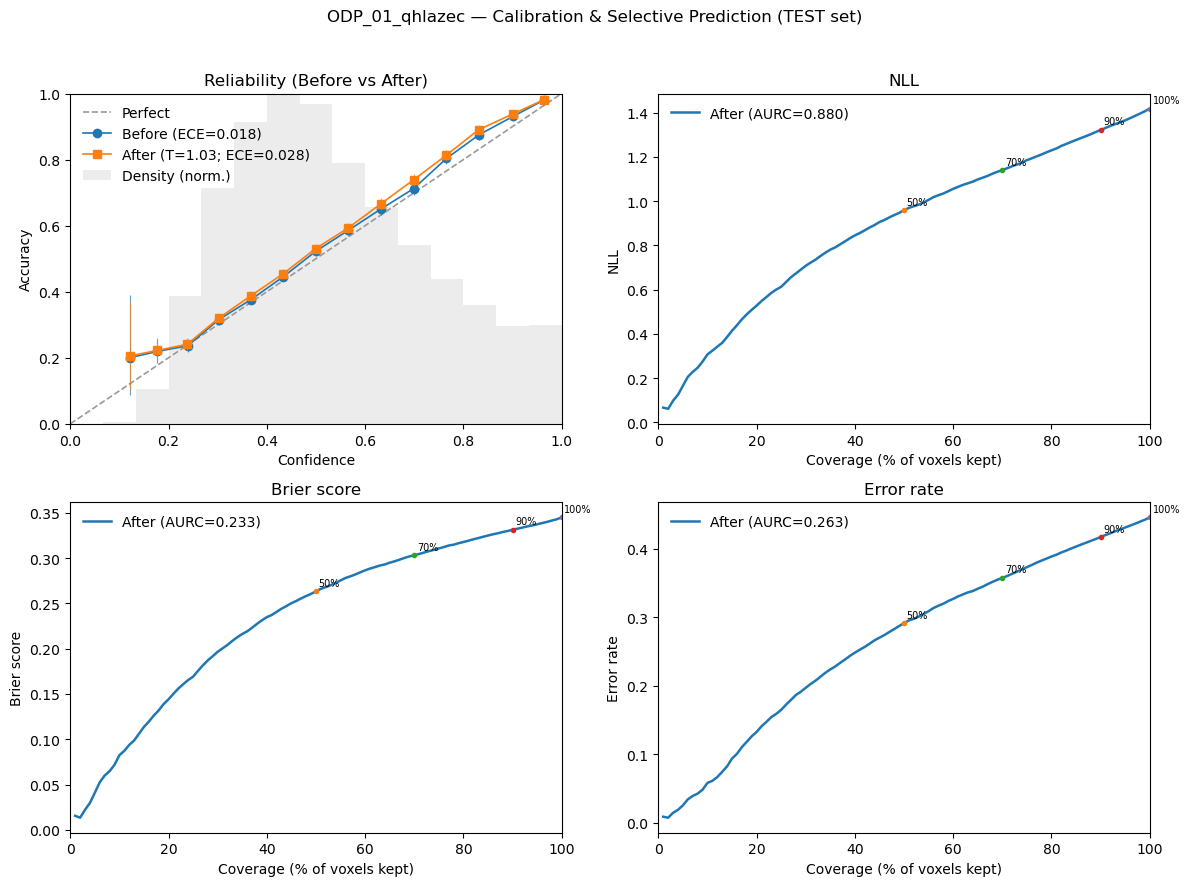

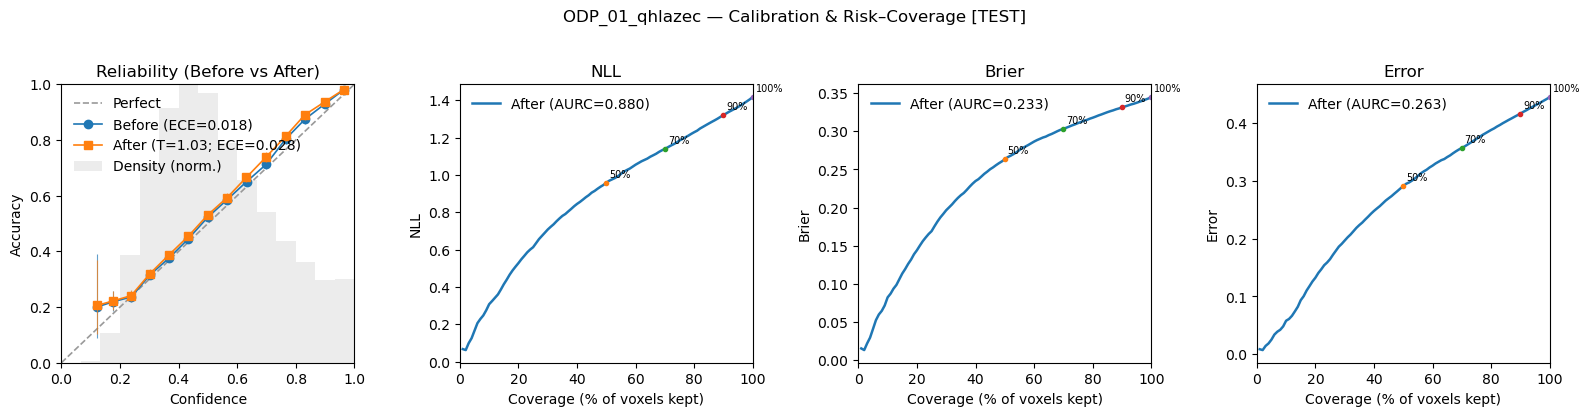

In [24]:
# ====== B. 可靠性 + 风险-覆盖（白底 + Wilson CI + AURC 双曲线） ======
import numpy as np
import matplotlib.pyplot as plt

def _wilson_ci(k, n, z=1.95996398454):
    if n <= 0: return (np.nan, np.nan)
    phat = k / n
    denom = 1.0 + z**2 / n
    center = (phat + z**2/(2*n)) / denom
    margin = z * np.sqrt((phat*(1-phat)/n) + (z**2/(4*n**2))) / denom
    return center - margin, center + margin

def draw_reliability(ax, bin_before, bin_after, ece_b, ece_a, T_opt, n_bins=15):
    # 45° 线
    ax.plot([0,1],[0,1], ls='--', lw=1.2, color='0.6', label='Perfect')

    # before
    cb, ab, nb = np.array(bin_before['confidences']), np.array(bin_before['accuracies']), np.array(bin_before['counts'])
    ax.plot(cb, ab, marker='o', lw=1.2, label=f'Before (ECE={ece_b:.3f})')
    for c,a,n in zip(cb,ab,nb):
        lo, hi = _wilson_ci(int(round(a*n)), int(n))
        if np.isfinite(lo):
            ax.vlines(c, lo, hi, lw=0.8, color='C0', alpha=0.7)

    # after
    ca, aa, na = np.array(bin_after['confidences']), np.array(bin_after['accuracies']), np.array(bin_after['counts'])
    ax.plot(ca, aa, marker='s', lw=1.2, label=f'After (T={T_opt:.2f}; ECE={ece_a:.3f})')
    for c,a,n in zip(ca,aa,na):
        lo, hi = _wilson_ci(int(round(a*n)), int(n))
        if np.isfinite(lo):
            ax.vlines(c, lo, hi, lw=0.8, color='C1', alpha=0.7)

    # 样本密度（灰条）
    counts = nb
    if counts.sum() > 0:
        ax.bar(bin_before['bin_centers'], counts / counts.max(), width=1/n_bins, alpha=0.15, color='0.5', label='Density (norm.)')

    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
    ax.legend(frameon=False, loc='upper left')
    ax.set_title('Reliability (Before vs After)')

def _aurc(coverage, risk):
    coverage = np.asarray(coverage); risk = np.asarray(risk)
    # 保证 coverage 单调
    order = np.argsort(coverage)
    return float(np.trapz(risk[order], coverage[order]))

def draw_risk_curve(ax, cov_after, risk_after, title, cov_before=None, risk_before=None):
    """支持 before/after；若未提供 before，只画 after"""
    if cov_before is not None and risk_before is not None:
        aurc_b = _aurc(cov_before, risk_before)
        ax.plot(cov_before*100, risk_before, lw=1.5, label=f'Before (AURC={aurc_b:.3f})')
    aurc_a = _aurc(cov_after, risk_after)
    ax.plot(cov_after*100, risk_after, lw=1.8, label=f'After (AURC={aurc_a:.3f})')

    # 标注关键 coverage
    for cp in (0.5, 0.7, 0.9, 1.0):
        if cp <= np.max(cov_after):
            i = np.argmin(np.abs(cov_after - cp))
            ax.plot(cp*100, risk_after[i], 'o', ms=3)
            ax.annotate(f'{int(cp*100)}%', (cp*100, risk_after[i]),
                        textcoords="offset points", xytext=(2, 4), fontsize=7)

    ax.set_xlim(0,100)
    ax.set_xlabel('Coverage (% of voxels kept)'); ax.set_ylabel(title)
    ax.legend(frameon=False, loc='best')
    ax.set_title(title)

# -------- 合并图（2×2 与 1×4），如果有 *_before 数组就自动画双曲线 --------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
draw_reliability(axes[0,0], bin_data_before, bin_data_after, ece_before, ece_after, T_optimal, n_bins=15)

# Risk–coverage（这里演示 NLL；若你已计算 *_before 数组，就传进去）
draw_risk_curve(axes[0,1], coverages, nll_at_coverage, 'NLL',
                cov_before=globals().get('coverages_before'),
                risk_before=globals().get('nll_at_coverage_before'))
draw_risk_curve(axes[1,0], coverages, brier_at_coverage, 'Brier score',
                cov_before=globals().get('coverages_before'),
                risk_before=globals().get('brier_at_coverage_before'))
draw_risk_curve(axes[1,1], coverages, error_at_coverage, 'Error rate',
                cov_before=globals().get('coverages_before'),
                risk_before=globals().get('error_at_coverage_before'))

fig.suptitle(f'{SUBJECT_ID} — Calibration & Selective Prediction ({SPLIT_TYPE.upper()} set)', y=0.98, fontsize=12)
plt.tight_layout(rect=[0,0,1,0.96])
save_path_2x2 = OUTPUT_DIR / f'{SUBJECT_ID}_{SPLIT_TYPE}_combined_2x2.png'
plt.savefig(save_path_2x2, dpi=300, bbox_inches='tight')
print(f"✓ 已保存合并图（2×2）: {save_path_2x2.name}")
# plt.close(fig)

# 横向 1×4
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
draw_reliability(axes[0], bin_data_before, bin_data_after, ece_before, ece_after, T_optimal, n_bins=15)
draw_risk_curve(axes[1], coverages, nll_at_coverage, 'NLL',
                cov_before=globals().get('coverages_before'),
                risk_before=globals().get('nll_at_coverage_before'))
draw_risk_curve(axes[2], coverages, brier_at_coverage, 'Brier',
                cov_before=globals().get('coverages_before'),
                risk_before=globals().get('brier_at_coverage_before'))
draw_risk_curve(axes[3], coverages, error_at_coverage, 'Error',
                cov_before=globals().get('coverages_before'),
                risk_before=globals().get('error_at_coverage_before'))
fig.suptitle(f'{SUBJECT_ID} — Calibration & Risk–Coverage [{SPLIT_TYPE.upper()}]', y=0.98, fontsize=12)
plt.tight_layout(rect=[0,0,1,0.96])
save_path_1x4 = OUTPUT_DIR / f'{SUBJECT_ID}_{SPLIT_TYPE}_combined_1x4.png'
plt.savefig(save_path_1x4, dpi=300, bbox_inches='tight')
print(f"✓ 已保存合并图（1×4）: {save_path_1x4.name}")
# plt.close(fig)


Generating Figure 4: Advanced Analysis...
✓ 聚合软混淆完成: 37 折


/tmp/ipykernel_2934374/187711055.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Saved: /home/jovyan/gpu_space/workspace_jiayi/KAN-git/KAN-Brain-Single-Voxel-Segmentaion/3D_dev/training/downsampling/runs/loso_37fold/fold_01_test_ODP_01_qhlazec/figs/confidence_overlay/figure4_advanced_analysis.png


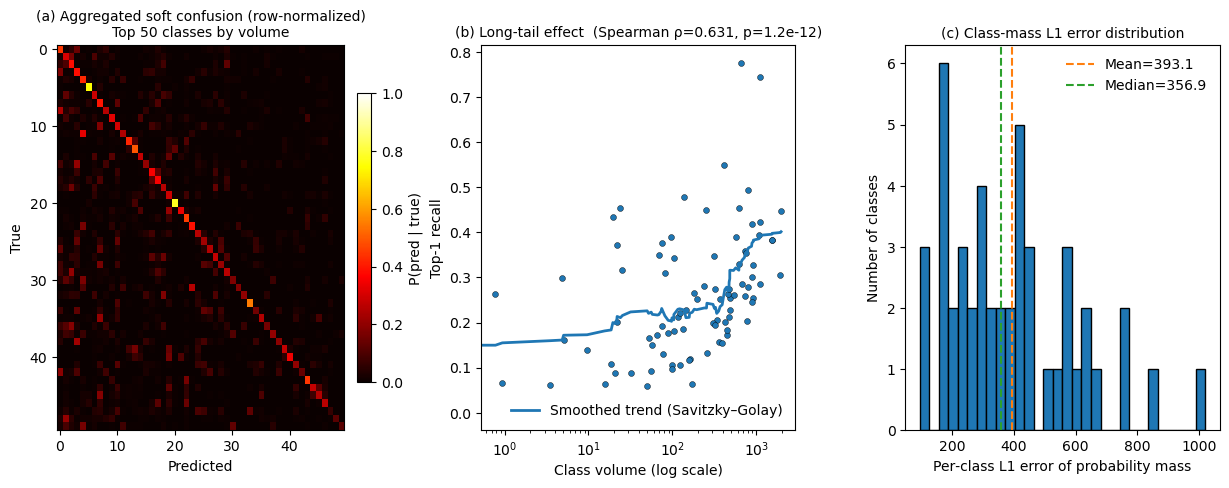

In [26]:
# ====== C. Figure 4：Aggregated Soft CM + Long-tail + L1 Error ======
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
from collections import defaultdict
from scipy.stats import spearmanr

print("Generating Figure 4: Advanced Analysis...")

# 依赖外部：N_CLASSES, fold_dirs, LABEL_NAMES, SUBJECT_ID, gt_proba, region_mask, OUTPUT_DIR
n_classes = int(N_CLASSES)

# ---------- 1) 读取并聚合软混淆 ----------
soft_cm_list = []
for fold_dir in fold_dirs:
    p = Path(fold_dir) / 'soft_confusion_test.csv'
    if p.exists():
        cm = np.loadtxt(p, delimiter=',')
        if cm.shape == (n_classes, n_classes):
            soft_cm_list.append(cm)
        else:
            print(f"  ⚠️ {fold_dir} 形状异常: {cm.shape}")

if len(soft_cm_list) == 0:
    aggregated_soft_cm = None
    print("❌ 没有发现 soft_confusion_test.csv，跳过 4a。")
else:
    aggregated_soft_cm = np.mean(soft_cm_list, axis=0)
    # 行归一（true class 条件分布）
    row_sum = aggregated_soft_cm.sum(axis=1, keepdims=True) + 1e-12
    aggregated_soft_cm = aggregated_soft_cm / row_sum
    print(f"✓ 聚合软混淆完成: {len(soft_cm_list)} 折")

# ---------- 2) 计算 per-class 指标与体素体量 ----------
stats = {"class_id": np.arange(n_classes), "class_name": [], "recall": [], "precision": [], "f1": [], "volume": []}

if aggregated_soft_cm is not None:
    # 按行归一后，对角线就是 recall
    recall = np.diag(aggregated_soft_cm)

    # 列归一得到 precision（pred 条件），为避免零除单独计算
    col_sum = aggregated_soft_cm.sum(axis=0, keepdims=True) + 1e-12
    prec_mat = aggregated_soft_cm / col_sum
    precision = np.diag(prec_mat)

    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    stats["recall"] = recall.tolist()
    stats["precision"] = precision.tolist()
    stats["f1"] = f1.tolist()
else:
    stats["recall"] = [np.nan]*n_classes
    stats["precision"] = [np.nan]*n_classes
    stats["f1"] = [np.nan]*n_classes

# 体素体量：用当前受试者的 soft label（真实数据，不做随机）
if 'gt_proba' in globals() and 'region_mask' in globals():
    roi_mask = (region_mask > 0)
    vol = np.einsum('ijkc,ijk->c', gt_proba, roi_mask.astype(float))
    stats["volume"] = vol.tolist()
else:
    print("❌ 缺少 gt_proba/region_mask，无法计算体量；该面板将提示缺失。")
    stats["volume"] = [np.nan]*n_classes

for cid in range(n_classes):
    stats["class_name"].append(LABEL_NAMES.get(cid, f'Class_{cid}'))

df = pd.DataFrame(stats)

# ---------- 3) 聚合 L1 误差（仅真实读取） ----------
class_mass_errors = defaultdict(list)
for fold_dir in fold_dirs:
    mp = Path(fold_dir) / 'metrics_test.json'
    if mp.exists():
        try:
            with open(mp, 'r') as f:
                metrics = json.load(f)
            for ei in metrics.get('class_mass_top_errors', []):
                class_mass_errors[ei['class_id']].append(float(ei['abs_error']))
        except Exception as e:
            print(f"  ⚠️ 读取 {mp} 失败: {e}")

avg_l1 = [np.mean(class_mass_errors[c]) if c in class_mass_errors and len(class_mass_errors[c])>0 else np.nan
          for c in range(n_classes)]

# ---------- 4) 选择展示次序（这里按体量排序，更诚实；若你有邻接矩阵可替换） ----------
valid_vol_mask = np.isfinite(df['volume'].values)
if valid_vol_mask.any():
    order_by_vol = np.argsort(df.loc[valid_vol_mask, 'volume'].values)[::-1]
    ordered_ids = df.index[valid_vol_mask][order_by_vol].values
    top_k = min(50, len(ordered_ids))
    anatomical_order = ordered_ids[:top_k]
else:
    anatomical_order = np.arange(min(50, n_classes))
    print("⚠️ 未能计算体量，临时使用 ID 顺序（非随机）。")

# ---------- 5) 绘图 ----------
fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(1, 3, wspace=0.35)

# (a) 软混淆矩阵（行归一）
ax1 = fig.add_subplot(gs[0,0])
if aggregated_soft_cm is not None:
    cm_sub = aggregated_soft_cm[np.ix_(anatomical_order, anatomical_order)]
    im = ax1.imshow(cm_sub, aspect='auto', vmin=0, vmax=1, cmap='hot')
    ax1.set_title(f'(a) Aggregated soft confusion (row‑normalized)\nTop {len(anatomical_order)} classes by volume', fontsize=10)
    ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')
    cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label('P(pred | true)')
    # 每 10 类打一个刻度
    ticks = np.arange(0, len(anatomical_order), 10)
    ax1.set_xticks(ticks); ax1.set_yticks(ticks)
else:
    ax1.text(0.5, 0.5, 'Soft confusion not available', ha='center', va='center')
    ax1.set_axis_off()

# (b) 长尾：体量 vs Top‑1 recall（Spearman ρ）
ax2 = fig.add_subplot(gs[0,1])
df_valid = df[np.isfinite(df['volume']) & np.isfinite(df['recall'])]
if len(df_valid) > 0:
    x = df_valid['volume'].values
    y = df_valid['recall'].values
    sc = ax2.scatter(x, y, s=18, edgecolor='k', linewidth=0.3)
    # 平滑趋势（Savitzky–Golay）
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    if len(xs) >= 11:
        win = (len(xs)//3) | 1  # odd
        win = max(11, min(win, 51) | 1)
        y_smooth = savgol_filter(ys, window_length=win, polyorder=2)
        ax2.plot(xs, y_smooth, lw=2, label='Smoothed trend (Savitzky–Golay)')
    rho, p = spearmanr(x, y)
    ax2.set_xscale('log')
    ax2.set_xlabel('Class volume (log scale)'); ax2.set_ylabel('Top‑1 recall')
    ax2.set_title(f'(b) Long‑tail effect  (Spearman ρ={rho:.3f}, p={p:.2g})', fontsize=10)
    ax2.legend(frameon=False, loc='lower right')
else:
    ax2.text(0.5, 0.5, 'Volume/recall not available', ha='center', va='center')
    ax2.set_axis_off()

# (c) 类质量 L1 误差分布（仅真实读取）
ax3 = fig.add_subplot(gs[0,2])
valid_err = np.array([e for e in avg_l1 if np.isfinite(e)])
if valid_err.size > 0:
    ax3.hist(valid_err, bins=30, edgecolor='k')
    ax3.axvline(valid_err.mean(), color='C1', ls='--', lw=1.5, label=f'Mean={valid_err.mean():.1f}')
    ax3.axvline(np.median(valid_err), color='C2', ls='--', lw=1.5, label=f'Median={np.median(valid_err):.1f}')
    ax3.set_xlabel('Per‑class L1 error of probability mass')
    ax3.set_ylabel('Number of classes')
    ax3.set_title('(c) Class‑mass L1 error distribution', fontsize=10)
    ax3.legend(frameon=False)
else:
    ax3.text(0.5, 0.5, 'L1 error not available', ha='center', va='center')
    ax3.set_axis_off()

plt.tight_layout()
save_path = OUTPUT_DIR / 'figure4_advanced_analysis.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
# plt.close(fig)


In [ ]:
# softece 和hard ece

print("="*80)
print("LOSO Cross-Validation Results Summary")
print("="*80)

import json
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

# ============================================================================
# Configuration - Use BASE_RESULT_DIR from Cell 2
# ============================================================================

# BASE_RESULT_DIR should already be defined in Cell 2
# If running standalone, uncomment and set:
# BASE_RESULT_DIR = Path("/home/jovyan/gpu_space/workspace_jiayi/KAN-git/KAN-Brain-Single-Voxel-Segmentaion/3D_dev/training/downsampling/runs/loso_37fold")

print(f"Scanning directory: {BASE_RESULT_DIR}")
print(f"Directory exists: {BASE_RESULT_DIR.exists()}")

# ============================================================================
# Scan all fold directories
# ============================================================================

fold_dirs = sorted(BASE_RESULT_DIR.glob("fold_*"))
print(f"Found {len(fold_dirs)} fold directories")

if len(fold_dirs) == 0:
    print("⚠️  No fold directories found!")
    print("Please check BASE_RESULT_DIR path.")
else:
    # ========================================================================
    # Collect metrics from each fold
    # ========================================================================
    
    metrics_collection = {
        'fold_name': [],
        'test_subject': [],
        'top1_accuracy': [],
        'top3_accuracy': [],
        'top5_accuracy': [],
        'nll': [],
        'soft_ece': [],  # Soft ECE (基于概率)
        'hard_ece': [],  # Hard ECE (基于预测类别)
        'mce': [],       # Maximum Calibration Error
        'macro_f1': [],
        'weighted_f1': [],  # 添加weighted F1
        '3d_soft_dice_macro': [],
        '3d_hard_dice_macro': [],  # 添加hard dice
        'brier_score': []  # 添加Brier Score
    }
    
    print("Collecting metrics from each fold...")
    
    for fold_dir in fold_dirs:
        fold_name = fold_dir.name
        
        # Try to read run_summary.json first (preferred)
        summary_path = fold_dir / 'run_summary.json'
        test_metrics_path = fold_dir / 'metrics_test.json'
        
        metrics_data = None
        
        if summary_path.exists():
            try:
                with open(summary_path, 'r') as f:
                    data = json.load(f)
                
                # Extract from run_summary.json
                test_metrics = data.get('test_metrics', {})
                
                # Extract test subject from fold_name
                parts = fold_name.split('_')
                test_subject = '_'.join(parts[3:]) if len(parts) > 3 else 'unknown'
                
                # Get both soft and hard ECE if available
                soft_ece = test_metrics.get('soft_ece', test_metrics.get('ece', np.nan))
                hard_ece = test_metrics.get('hard_ece', test_metrics.get('ece', np.nan))
                
                # 如果只有一个ECE值，根据上下文判断是soft还是hard
                if 'ece' in test_metrics and 'soft_ece' not in test_metrics and 'hard_ece' not in test_metrics:
                    # 默认认为是soft ECE（因为大多数实现使用soft）
                    soft_ece = test_metrics['ece']
                    hard_ece = np.nan  # 需要重新计算
                
                metrics_data = {
                    'fold_name': fold_name,
                    'test_subject': test_subject,
                    'top1_accuracy': test_metrics.get('gross_accuracy', np.nan),
                    'top3_accuracy': test_metrics.get('top3_accuracy', np.nan),
                    'top5_accuracy': test_metrics.get('top5_accuracy', np.nan),
                    'nll': test_metrics.get('nll', np.nan),
                    'soft_ece': soft_ece,
                    'hard_ece': hard_ece,
                    'mce': test_metrics.get('mce', np.nan),
                    'macro_f1': test_metrics.get('macro_f1', np.nan),
                    'weighted_f1': test_metrics.get('weighted_f1', np.nan),
                    '3d_soft_dice_macro': data.get('test_3d_soft_dice_macro', np.nan),
                    '3d_hard_dice_macro': data.get('test_3d_hard_dice_macro', np.nan),
                    'brier_score': test_metrics.get('brier_score', np.nan)
                }
                
                # 如果缺少hard_ece，尝试从原始预测数据计算
                if np.isnan(metrics_data['hard_ece']):
                    pred_file = fold_dir / 'pred_3d' / f'test_{test_subject}_pred_softmax_3d.npz'
                    gt_file = Path(f"/home/jovyan/gpu_space/workspace_jiayi/alex_datasets/downsampling/3d/{test_subject}_3d.npz")
                    
                    if pred_file.exists() and gt_file.exists():
                        try:
                            # 计算Hard ECE
                            pred_data = np.load(pred_file)
                            gt_data = np.load(gt_file)
                            
                            pred_softmax = pred_data['pred_softmax_3d']
                            gt_proba = gt_data['proba_labels']
                            region_mask = gt_data['region_mask_lr']
                            
                            # 只在ROI内计算
                            pred_roi = pred_softmax[region_mask > 0]
                            gt_roi = gt_proba[region_mask > 0]
                            gt_labels = np.argmax(gt_roi, axis=-1)
                            
                            # Hard predictions
                            pred_labels = np.argmax(pred_roi, axis=-1)
                            pred_confidence = np.max(pred_roi, axis=-1)
                            
                            # 计算Hard ECE
                            n_bins = 15
                            bin_boundaries = np.linspace(0, 1, n_bins + 1)
                            hard_ece = 0.0
                            
                            for i in range(n_bins):
                                bin_mask = (pred_confidence >= bin_boundaries[i]) & (pred_confidence < bin_boundaries[i+1])
                                if i == n_bins - 1:  # 包含最大值
                                    bin_mask = (pred_confidence >= bin_boundaries[i]) & (pred_confidence <= bin_boundaries[i+1])
                                
                                if bin_mask.sum() > 0:
                                    bin_confidence = pred_confidence[bin_mask].mean()
                                    bin_accuracy = (pred_labels[bin_mask] == gt_labels[bin_mask]).mean()
                                    hard_ece += bin_mask.sum() * np.abs(bin_confidence - bin_accuracy)
                            
                            hard_ece = hard_ece / len(pred_labels)
                            metrics_data['hard_ece'] = hard_ece
                            
                            # 同时计算Brier Score如果缺失
                            if np.isnan(metrics_data['brier_score']):
                                gt_one_hot = np.eye(pred_roi.shape[-1])[gt_labels]
                                brier_score = np.mean(np.sum((pred_roi - gt_one_hot)**2, axis=1))
                                metrics_data['brier_score'] = brier_score
                            
                        except Exception as e:
                            print(f"    Could not compute hard_ece for {fold_name}: {str(e)}")
                
                print(f"  ✓ {fold_name}: Top1={metrics_data['top1_accuracy']:.4f}, " + 
                      f"Soft_ECE={metrics_data['soft_ece']:.4f if not np.isnan(metrics_data['soft_ece']) else 0:.4f}, " +
                      f"Hard_ECE={metrics_data['hard_ece']:.4f if not np.isnan(metrics_data['hard_ece']) else 0:.4f}")
                
            except Exception as e:
                print(f"  ⚠️  {fold_name}: Error reading run_summary.json - {str(e)}")
                continue
        
        else:
            print(f"  ⚠️  {fold_name}: No metrics files found")
            continue
        
        # Add to collection
        if metrics_data is not None:
            for key in metrics_collection.keys():
                metrics_collection[key].append(metrics_data[key])
    
    # ========================================================================
    # Create DataFrame and compute statistics
    # ========================================================================
    
    df_metrics = pd.DataFrame(metrics_collection)
    
    print(f"\nSuccessfully collected metrics from {len(df_metrics)} folds")
    
    # ========================================================================
    # Compute Mean ± Std
    # ========================================================================
    
    print("\n" + "="*80)
    print("LOSO Cross-Validation Results (Mean ± Std)")
    print("="*80)
    
    # 定义要统计的指标
    metrics_to_summarize = [
        ('top1_accuracy', 'Top-1 Accuracy', True),
        ('top3_accuracy', 'Top-3 Accuracy', True),
        ('top5_accuracy', 'Top-5 Accuracy', True),
        ('nll', 'NLL', False),
        ('soft_ece', 'ECE (Soft/Probability-based)', False),
        ('hard_ece', 'ECE (Hard/Class-based)', False),
        ('mce', 'MCE (Maximum Calibration Error)', False),
        ('brier_score', 'Brier Score', False),
        ('macro_f1', 'Macro F1', False),
        ('weighted_f1', 'Weighted F1', False),
        ('3d_soft_dice_macro', '3D Soft Dice (Macro)', False),
        ('3d_hard_dice_macro', '3D Hard Dice (Macro)', False)
    ]
    
    summary_data = []
    
    for metric_key, metric_name, is_percentage in metrics_to_summarize:
        values = df_metrics[metric_key].values
        
        # Filter out NaN values
        values_clean = values[~np.isnan(values)]
        
        if len(values_clean) > 0:
            mean_val = np.mean(values_clean)
            std_val = np.std(values_clean, ddof=1)
            min_val = np.min(values_clean)
            max_val = np.max(values_clean)
            median_val = np.median(values_clean)
            n_folds = len(values_clean)
            
            if is_percentage:
                summary_data.append({
                    'Metric': metric_name,
                    'Mean ± Std': f"{mean_val*100:.2f}% ± {std_val*100:.2f}%",
                    'Median': f"{median_val*100:.2f}%",
                    'Range': f"[{min_val*100:.2f}%, {max_val*100:.2f}%]",
                    'N': n_folds
                })
                
                print(f"\n{metric_name}:")
                print(f"  Mean ± Std: {mean_val*100:.2f}% ± {std_val*100:.2f}%")
                print(f"  Median: {median_val*100:.2f}%")
                print(f"  Range: [{min_val*100:.2f}%, {max_val*100:.2f}%]")
                print(f"  N: {n_folds}")
            else:
                summary_data.append({
                    'Metric': metric_name,
                    'Mean ± Std': f"{mean_val:.4f} ± {std_val:.4f}",
                    'Median': f"{median_val:.4f}",
                    'Range': f"[{min_val:.4f}, {max_val:.4f}]",
                    'N': n_folds
                })
                
                print(f"\n{metric_name}:")
                print(f"  Mean ± Std: {mean_val:.4f} ± {std_val:.4f}")
                print(f"  Median: {median_val:.4f}")
                print(f"  Range: [{min_val:.4f}, {max_val:.4f}]")
                print(f"  N: {n_folds}")
        else:
            summary_data.append({
                'Metric': metric_name,
                'Mean ± Std': 'N/A',
                'Median': 'N/A',
                'Range': 'N/A',
                'N': 0
            })
            print(f"\n{metric_name}: No valid data")
    
    print("\n" + "="*80)
    
    # ========================================================================
    # Display summary table
    # ========================================================================
    
    df_summary = pd.DataFrame(summary_data)
    
    print("\n\nSummary Table:")
    print("="*80)
    display(df_summary)
    
    # ========================================================================
    # 显示Soft vs Hard ECE的对比
    # ========================================================================
    
    soft_ece_vals = df_metrics['soft_ece'].values[~np.isnan(df_metrics['soft_ece'].values)]
    hard_ece_vals = df_metrics['hard_ece'].values[~np.isnan(df_metrics['hard_ece'].values)]
    
    if len(soft_ece_vals) > 0 and len(hard_ece_vals) > 0:
        print("\n" + "="*80)
        print("ECE Comparison (Soft vs Hard)")
        print("="*80)
        print(f"Soft ECE: {np.mean(soft_ece_vals):.4f} ± {np.std(soft_ece_vals, ddof=1):.4f}")
        print(f"Hard ECE: {np.mean(hard_ece_vals):.4f} ± {np.std(hard_ece_vals, ddof=1):.4f}")
        print(f"Difference (Soft - Hard): {np.mean(soft_ece_vals) - np.mean(hard_ece_vals):.4f}")
        print("="*80)
    
    # ========================================================================
    # Save summary to CSV
    # ========================================================================
    
    summary_csv_path = BASE_RESULT_DIR / 'loso_summary_statistics.csv'
    df_summary.to_csv(summary_csv_path, index=False)
    print(f"\n✓ Summary saved to: {summary_csv_path}")
    
    # Also save detailed per-fold data
    detailed_csv_path = BASE_RESULT_DIR / 'loso_detailed_metrics.csv'
    df_metrics.to_csv(detailed_csv_path, index=False)
    print(f"✓ Detailed metrics saved to: {detailed_csv_path}")
    
    # ========================================================================
    # 创建ECE对比可视化
    # ========================================================================
    
    if len(soft_ece_vals) > 0 and len(hard_ece_vals) > 0:
        import matplotlib.pyplot as plt
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # 箱线图对比
        ax = axes[0]
        bp = ax.boxplot([soft_ece_vals, hard_ece_vals], 
                        labels=['Soft ECE\n(Probability-based)', 'Hard ECE\n(Class-based)'],
                        patch_artist=True,
                        boxprops=dict(facecolor='lightblue', alpha=0.8),
                        medianprops=dict(color='red', linewidth=2),
                        whiskerprops=dict(linewidth=1.5),
                        capprops=dict(linewidth=1.5))
        
        # 添加均值标记
        ax.scatter([1, 2], [np.mean(soft_ece_vals), np.mean(hard_ece_vals)], 
                  color='green', s=100, marker='D', zorder=5, label='Mean')
        
        ax.set_ylabel('ECE Value', fontsize=11)
        ax.set_title('ECE Distribution Comparison', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle=':')
        ax.legend(loc='upper right')
        
        # 添加数值标注
        for i, (vals, name) in enumerate([(soft_ece_vals, 'Soft'), (hard_ece_vals, 'Hard')], 1):
            ax.text(i, np.max(vals) + 0.002, 
                   f'μ={np.mean(vals):.4f}\nσ={np.std(vals, ddof=1):.4f}',
                   ha='center', va='bottom', fontsize=9)
        
        # 折线图显示每个fold的对比
        ax = axes[1]
        
        # 获取配对的数据
        paired_indices = []
        paired_soft = []
        paired_hard = []
        
        for i in range(len(df_metrics)):
            if not np.isnan(df_metrics.iloc[i]['soft_ece']) and not np.isnan(df_metrics.iloc[i]['hard_ece']):
                paired_indices.append(i)
                paired_soft.append(df_metrics.iloc[i]['soft_ece'])
                paired_hard.append(df_metrics.iloc[i]['hard_ece'])
        
        if len(paired_indices) > 0:
            x_pos = np.arange(len(paired_indices))
            ax.plot(x_pos, paired_soft, 'o-', label='Soft ECE', linewidth=1.5, markersize=6)
            ax.plot(x_pos, paired_hard, 's-', label='Hard ECE', linewidth=1.5, markersize=6)
            
            # 添加差异阴影
            ax.fill_between(x_pos, paired_soft, paired_hard, alpha=0.2, color='gray')
            
            ax.set_xlabel('Fold Index', fontsize=11)
            ax.set_ylabel('ECE Value', fontsize=11)
            ax.set_title('ECE Values Across Folds', fontsize=12, fontweight='bold')
            ax.legend(loc='best')
            ax.grid(alpha=0.3, linestyle=':')
            
            # 设置x轴标签
            if len(x_pos) <= 20:
                ax.set_xticks(x_pos)
                ax.set_xticklabels([df_metrics.iloc[i]['test_subject'].replace('ODP_', '').replace('_', '-') 
                                   for i in paired_indices], rotation=45, ha='right', fontsize=8)
        
        plt.suptitle('ECE Calibration Comparison: Soft vs Hard', fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        
        # 保存图表
        ece_comparison_path = BASE_RESULT_DIR / 'ece_soft_vs_hard_comparison.png'
        plt.savefig(ece_comparison_path, dpi=200, bbox_inches='tight')
        print(f"\n✓ ECE comparison plot saved to: {ece_comparison_path}")
        plt.show()
    
    print("\n" + "="*80)
    print("✓ LOSO Summary Complete with Hard/Soft ECE Analysis!")
    print("="*80)

In [ ]:
# ====== 版本1：Hard ECE - 基于预测类别的校准分析 ======
import numpy as np
import matplotlib.pyplot as plt

def compute_hard_ece_metrics(pred_probs, true_labels, n_bins=15):
    """
    计算Hard ECE - 基于最高概率类别的置信度
    """
    # 获取预测类别和置信度
    pred_labels = np.argmax(pred_probs, axis=-1)
    confidences = np.max(pred_probs, axis=-1)
    accuracies = (pred_labels == true_labels).astype(float)
    
    # 分箱计算
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2
    
    bin_accuracies = []
    bin_confidences = []
    bin_counts = []
    
    ece = 0.0
    total_samples = len(confidences)
    
    for i in range(n_bins):
        bin_mask = (confidences >= bin_boundaries[i]) & (confidences < bin_boundaries[i+1])
        if i == n_bins - 1:  # 最后一个bin包含上界
            bin_mask = (confidences >= bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        
        n_bin = bin_mask.sum()
        
        if n_bin > 0:
            bin_acc = accuracies[bin_mask].mean()
            bin_conf = confidences[bin_mask].mean()
            bin_accuracies.append(bin_acc)
            bin_confidences.append(bin_conf)
            bin_counts.append(n_bin)
            
            # ECE累加
            ece += (n_bin / total_samples) * np.abs(bin_conf - bin_acc)
        else:
            bin_accuracies.append(0)
            bin_confidences.append(bin_centers[i])
            bin_counts.append(0)
    
    # MCE (Maximum Calibration Error)
    mce = 0.0
    for acc, conf, count in zip(bin_accuracies, bin_confidences, bin_counts):
        if count > 0:
            mce = max(mce, np.abs(conf - acc))
    
    return {
        'bin_centers': bin_centers,
        'accuracies': np.array(bin_accuracies),
        'confidences': np.array(bin_confidences),
        'counts': np.array(bin_counts),
        'ece': ece,
        'mce': mce
    }

def _wilson_ci(k, n, z=1.95996398454):
    """计算Wilson置信区间"""
    if n <= 0: 
        return (np.nan, np.nan)
    phat = k / n
    denom = 1.0 + z**2 / n
    center = (phat + z**2/(2*n)) / denom
    margin = z * np.sqrt((phat*(1-phat)/n) + (z**2/(4*n**2))) / denom
    return center - margin, center + margin

def draw_reliability_hard_ece(ax, bin_data, T_opt, n_bins=15):
    """绘制Hard ECE的可靠性图"""
    # 完美校准线
    ax.plot([0,1], [0,1], ls='--', lw=1.2, color='gray', alpha=0.7, label='Perfect Calibration')
    
    # 校准后的结果
    confidences = bin_data['confidences']
    accuracies = bin_data['accuracies']
    counts = bin_data['counts']
    ece = bin_data['ece']
    mce = bin_data['mce']
    
    # 主线 - 使用方形标记表示Hard ECE
    ax.plot(confidences, accuracies, 
            marker='s', markersize=8, lw=2.0, 
            color='#d62728', label=f'Hard ECE (T={T_opt:.3f})')
    
    # Wilson置信区间
    for c, a, n in zip(confidences, accuracies, counts):
        if n > 0:
            lo, hi = _wilson_ci(int(round(a*n)), int(n))
            if np.isfinite(lo) and np.isfinite(hi):
                ax.vlines(c, lo, hi, lw=1.0, color='#d62728', alpha=0.6)
    
    # 样本密度分布
    if counts.sum() > 0:
        ax.bar(bin_data['bin_centers'], counts / counts.max(), 
               width=1/n_bins, alpha=0.15, color='gray', 
               label='Sample Density')
    
    # 添加ECE和MCE信息框
    textstr = f'Hard ECE: {ece:.4f}\nMCE: {mce:.4f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # 设置
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Confidence (Max Probability)', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.legend(frameon=True, loc='lower right', fontsize=9)
    ax.set_title('Reliability Diagram - Hard ECE', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

# ============================================================================
# 计算Hard ECE指标
# ============================================================================

print("计算Hard ECE指标...")

# 温度缩放后的预测
pred_scaled = pred_softmax / T_optimal
pred_scaled = np.exp(pred_scaled - np.max(pred_scaled, axis=-1, keepdims=True))
pred_scaled = pred_scaled / np.sum(pred_scaled, axis=-1, keepdims=True)

# 只在ROI内计算
pred_roi_scaled = pred_scaled[region_mask > 0]
gt_labels = np.argmax(gt_proba[region_mask > 0], axis=-1)

# 计算Hard ECE
hard_ece_metrics = compute_hard_ece_metrics(pred_roi_scaled, gt_labels, n_bins=15)

print(f"Hard ECE: {hard_ece_metrics['ece']:.4f}")
print(f"MCE: {hard_ece_metrics['mce']:.4f}")

# ============================================================================
# 绘图 - Hard ECE版本
# ============================================================================

# 2×2 布局
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) 可靠性图 - Hard ECE
draw_reliability_hard_ece(axes[0,0], hard_ece_metrics, T_optimal, n_bins=15)

# (2-4) 风险-覆盖曲线（这些保持不变）
from previous_code import draw_risk_curve_calibrated  # 使用之前定义的函数
draw_risk_curve_calibrated(axes[0,1], coverages_after, nll_after, 
                          'NLL Risk-Coverage', 'Negative Log-Likelihood')
draw_risk_curve_calibrated(axes[1,0], coverages_after, brier_after, 
                          'Brier Score Risk-Coverage', 'Brier Score')
draw_risk_curve_calibrated(axes[1,1], coverages_after, error_after, 
                          'Error Rate Risk-Coverage', 'Error Rate')

fig.suptitle(f'{SUBJECT_ID} — Calibrated Model (Hard ECE) [{SPLIT_TYPE.upper()}]', 
            fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])

save_path = OUTPUT_DIR / f'{SUBJECT_ID}_{SPLIT_TYPE}_hard_ece_analysis.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ 已保存Hard ECE分析图: {save_path.name}")

plt.show()

In [ ]:
# ====== 版本2：Soft ECE - 基于完整概率分布的校准分析 ======
import numpy as np
import matplotlib.pyplot as plt

def compute_soft_ece_metrics(pred_probs, true_one_hot, n_bins=15):
    """
    计算Soft ECE - 基于所有类别的概率
    """
    n_samples, n_classes = pred_probs.shape
    
    # 为每个类别计算ECE，然后平均
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2
    
    # 存储整体的bin统计
    overall_bin_accuracies = np.zeros(n_bins)
    overall_bin_confidences = np.zeros(n_bins)
    overall_bin_counts = np.zeros(n_bins)
    
    soft_ece = 0.0
    
    # 对每个概率值进行分箱
    for i in range(n_bins):
        bin_mask = np.zeros(n_samples * n_classes, dtype=bool)
        
        # 展平所有概率值
        all_probs = pred_probs.flatten()
        all_labels = true_one_hot.flatten()
        
        # 找到在当前bin范围内的概率值
        if i == n_bins - 1:
            bin_mask = (all_probs >= bin_boundaries[i]) & (all_probs <= bin_boundaries[i+1])
        else:
            bin_mask = (all_probs >= bin_boundaries[i]) & (all_probs < bin_boundaries[i+1])
        
        n_bin = bin_mask.sum()
        
        if n_bin > 0:
            bin_prob_mean = all_probs[bin_mask].mean()
            bin_label_mean = all_labels[bin_mask].mean()
            
            overall_bin_confidences[i] = bin_prob_mean
            overall_bin_accuracies[i] = bin_label_mean
            overall_bin_counts[i] = n_bin
            
            # Soft ECE累加
            soft_ece += (n_bin / (n_samples * n_classes)) * np.abs(bin_prob_mean - bin_label_mean)
        else:
            overall_bin_confidences[i] = bin_centers[i]
            overall_bin_accuracies[i] = bin_centers[i]
            overall_bin_counts[i] = 0
    
    # Soft MCE
    soft_mce = 0.0
    for acc, conf, count in zip(overall_bin_accuracies, overall_bin_confidences, overall_bin_counts):
        if count > 0:
            soft_mce = max(soft_mce, np.abs(conf - acc))
    
    return {
        'bin_centers': bin_centers,
        'accuracies': overall_bin_accuracies,
        'confidences': overall_bin_confidences,
        'counts': overall_bin_counts,
        'ece': soft_ece,
        'mce': soft_mce
    }

def draw_reliability_soft_ece(ax, bin_data, T_opt, n_bins=15):
    """绘制Soft ECE的可靠性图"""
    # 完美校准线
    ax.plot([0,1], [0,1], ls='--', lw=1.2, color='gray', alpha=0.7, label='Perfect Calibration')
    
    # 校准后的结果
    confidences = bin_data['confidences']
    accuracies = bin_data['accuracies']
    counts = bin_data['counts']
    ece = bin_data['ece']
    mce = bin_data['mce']
    
    # 主线 - 使用圆形标记表示Soft ECE
    ax.plot(confidences, accuracies, 
            marker='o', markersize=8, lw=2.0, 
            color='#1f77b4', label=f'Soft ECE (T={T_opt:.3f})')
    
    # Wilson置信区间
    for c, a, n in zip(confidences, accuracies, counts):
        if n > 0:
            lo, hi = _wilson_ci(int(round(a*n)), int(n))
            if np.isfinite(lo) and np.isfinite(hi):
                ax.vlines(c, lo, hi, lw=1.0, color='#1f77b4', alpha=0.6)
    
    # 样本密度分布
    if counts.sum() > 0:
        # 归一化显示
        normalized_counts = counts / counts.max()
        ax.bar(bin_data['bin_centers'], normalized_counts, 
               width=1/n_bins, alpha=0.15, color='gray', 
               label='Probability Density')
    
    # 添加ECE和MCE信息框
    textstr = f'Soft ECE: {ece:.4f}\nSoft MCE: {mce:.4f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # 设置
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Probability', fontsize=11)
    ax.set_ylabel('Empirical Frequency', fontsize=11)
    ax.legend(frameon=True, loc='lower right', fontsize=9)
    ax.set_title('Reliability Diagram - Soft ECE', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

# ============================================================================
# 计算Soft ECE指标
# ============================================================================

print("计算Soft ECE指标...")

# 温度缩放后的预测
pred_scaled = pred_softmax / T_optimal
pred_scaled = np.exp(pred_scaled - np.max(pred_scaled, axis=-1, keepdims=True))
pred_scaled = pred_scaled / np.sum(pred_scaled, axis=-1, keepdims=True)

# 只在ROI内计算
pred_roi_scaled = pred_scaled[region_mask > 0]
gt_one_hot = np.eye(N_CLASSES)[np.argmax(gt_proba[region_mask > 0], axis=-1)]

# 计算Soft ECE
soft_ece_metrics = compute_soft_ece_metrics(pred_roi_scaled, gt_one_hot, n_bins=15)

print(f"Soft ECE: {soft_ece_metrics['ece']:.4f}")
print(f"Soft MCE: {soft_ece_metrics['mce']:.4f}")

# ============================================================================
# 绘图 - Soft ECE版本
# ============================================================================

# 2×2 布局
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) 可靠性图 - Soft ECE
draw_reliability_soft_ece(axes[0,0], soft_ece_metrics, T_optimal, n_bins=15)

# (2-4) 风险-覆盖曲线
draw_risk_curve_calibrated(axes[0,1], coverages_after, nll_after, 
                          'NLL Risk-Coverage', 'Negative Log-Likelihood')
draw_risk_curve_calibrated(axes[1,0], coverages_after, brier_after, 
                          'Brier Score Risk-Coverage', 'Brier Score')
draw_risk_curve_calibrated(axes[1,1], coverages_after, error_after, 
                          'Error Rate Risk-Coverage', 'Error Rate')

fig.suptitle(f'{SUBJECT_ID} — Calibrated Model (Soft ECE) [{SPLIT_TYPE.upper()}]', 
            fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])

save_path = OUTPUT_DIR / f'{SUBJECT_ID}_{SPLIT_TYPE}_soft_ece_analysis.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ 已保存Soft ECE分析图: {save_path.name}")

plt.show()